# Dashboard LCA — adaptive plotting version

This version keeps the notebook as the single plotting/dashboard entry point, but replaces the fixed 48-slice plotting with adaptive figures.

What changed:

- It uses the active settings in `dashboard_config.py`, including `GRID_TIME_MODE = "single"`, `"range"`, or `"year_average"`.
- It loads both wind/grid output folders when `WIND_LCA_MODE = "both"`.
- It automatically switches between raw half-hourly plots, resampled daily/weekly/monthly plots, and categorical representative-day plots.
- It adds duration-curve and heatmap-style diagnostics so a full year does not become an unreadable spaghetti plot.
- It avoids hard-coded x-axis tick labels, so the same notebook works for one day, one week, one year, or the 12 representative `year_average` outputs.

Edit settings in `dashboard_config.py`, run the child notebooks if you need fresh outputs, then run the plotting cells below.


In [1]:
# All settings come from dashboard_config.py — the single master dashboard.
# Edit values there once; every notebook picks them up.
from pathlib import Path
from typing import Iterable, Optional, Sequence
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

from IPython.display import display

from dashboard_config import *
import dashboard_config as cfg

try:
    import lca_helpers as H
except Exception as exc:
    H = None
    warnings.warn(f"Could not import lca_helpers. Plotting still works, but child notebook execution may fail: {exc}")

print_dashboard()


Master Dashboard
----------------
Project:                 hydrogen-smr
Foreground DB:           hydrogen foreground
Build foreground DB:     True
Run reference LCA:       False
Run grid scenario LCA:   True
Run wind/grid LCA:       True
Grid method:             cheap | loss factor: 1.0316426921769999
Wind/grid method:        cheap
Selected grid techs:     ['PEM operation']
Wind/grid mode:          both (blended + switching) | electrolyser(s): ['AE operation']


## Optional: re-run the building-block notebooks

By default this dashboard only loads the latest CSV outputs and plots them. Set the flags below to `True` only when you want to regenerate results.


Master Dashboard
----------------
Project:                 hydrogen-smr
Foreground DB:           hydrogen foreground
Build foreground DB:     True
Run reference LCA:       False
Run grid scenario LCA:   True
Run wind/grid LCA:       True
Grid method:             cheap | loss factor: 1.0316426921769999
Wind/grid method:        cheap
Selected grid techs:     ['PEM operation']
Wind/grid mode:          both (blended + switching) | electrolyser(s): ['AE operation']

Current Brightway project: hydrogen-smr
Using ecoinvent database: ecoinvent-3.9.1-apos
Using biosphere database: ecoinvent-3.9.1-biosphere
Using foreground database: hydrogen foreground
Using LCIA method: ('ecoinvent-3.9.1', 'IPCC 2021 no LT', 'climate change no LT', 'global warming potential (GWP100) no LT')

electricity : market for electricity high voltage GB
    0 | name: electricity, high voltage, import from GB | ref: electricity, high voltage | unit: kilowatt hour | loc: BE
    1 | name: electricity, high voltage, import 

c:\Users\ls1524\AppData\Local\miniconda3\envs\brightway\Lib\site-packages\bw2data\backends\base.py:899: UserWarning: 
            Please use `del databases['hydrogen foreground']` instead.
            Otherwise, the metadata and database get out of sync.
            Call `.delete(warn=False)` to skip this message in the future.
            
  warnings.warn(MESSAGE.format(self.name), UserWarning)
100%|██████████| 10/10 [00:00<00:00, 314.90it/s]


12:55:01+0100 [info     ] Vacuuming database            
Foreground database written with 10 activities.

SMR → 'Hydrogen production, SMR Hermesmann' (kilogram, GB, None)
  production                1  kilogram         Hydrogen production, SMR Hermesmann
  technosphere           -1.1  kilowatt hour    market for electricity, high voltage
  technosphere           4.85  cubic meter      market for natural gas, high pressure
  technosphere           6.64  kilogram         market for tap water
  technosphere        6.6e-06  cubic meter      concrete, all types to generic market for concrete, normal strength
  technosphere        0.00506  kilogram         market for steel, unalloyed
  technosphere       4.17e-05  kilogram         market for aluminium, primary, cast alloy slab from continuous casting
  technosphere       6.18e-05  kilogram         market for cast iron
  technosphere        7.9e-10  unit             market for gas turbine, 10MW electrical
  technosphere        0.00172  cubic 

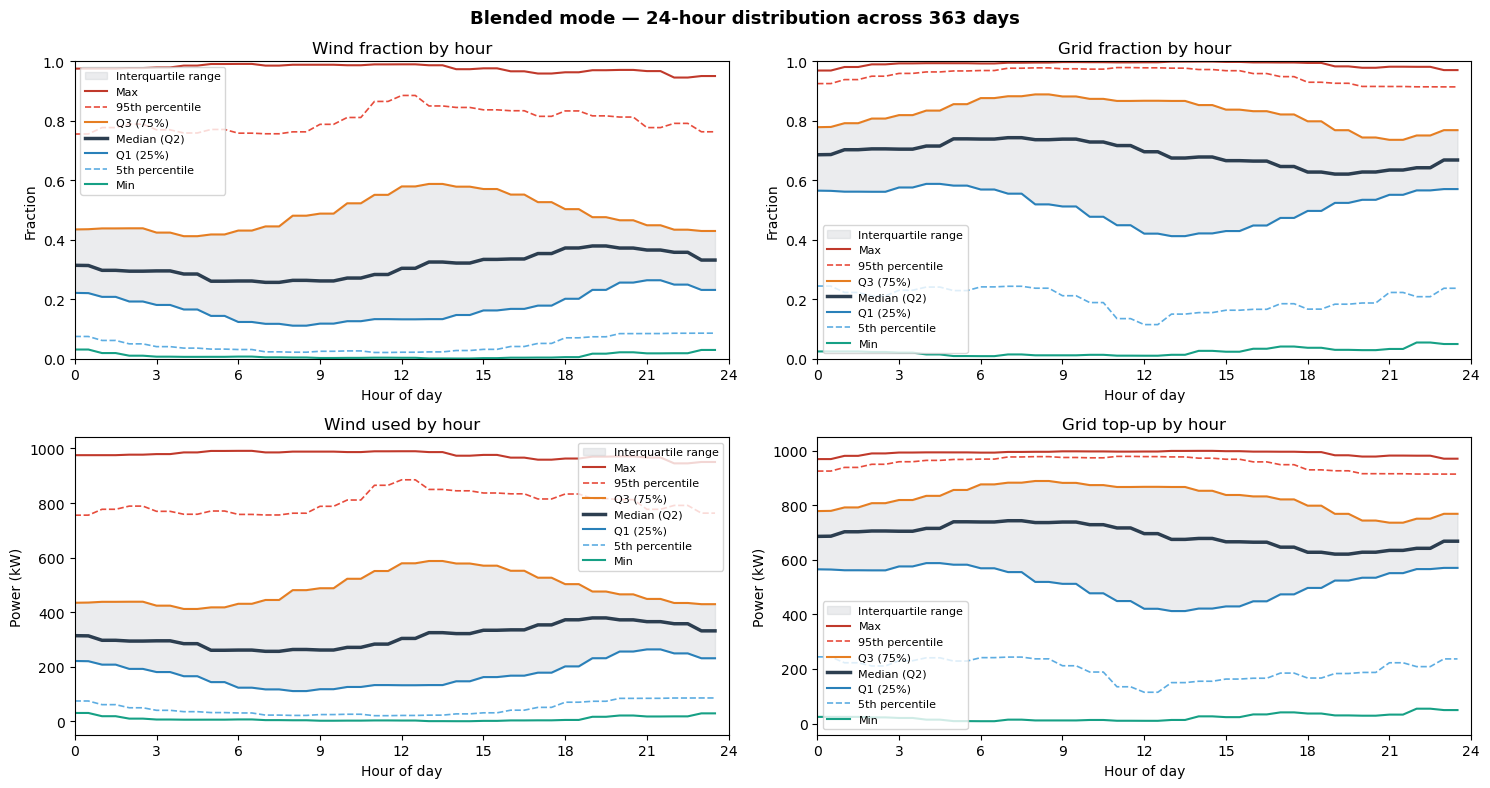

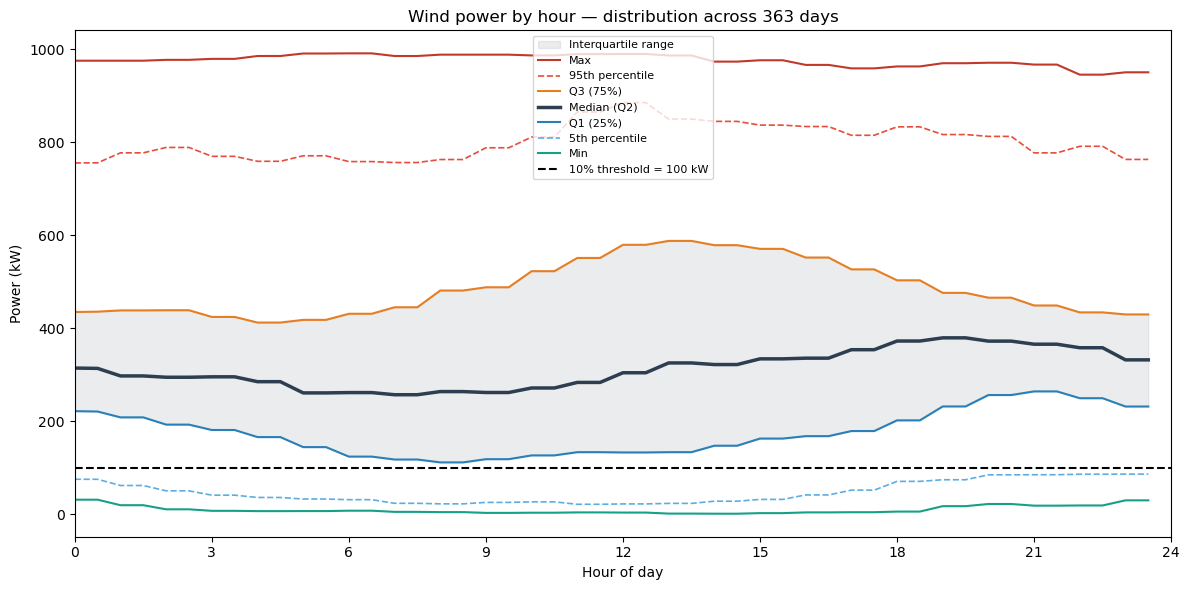

    0 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: GB
    1 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: NP
    2 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: RoW
    3 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: CA-QC
    4 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: CO
    5 | name: electricity production, wind, 1-3MW turbine, offshore | ref: electricity, high voltage | unit: kilowatt hour | loc: GB
    6 | name: electricity production, wind, >3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: GB
    7 | name: electricity production, wind, <1MW turbine, onshore | ref:

In [2]:
# Set to True only if you want to re-execute the child notebooks.
# For plotting existing CSVs, leave these as False.
RUN_FOREGROUND_NOTEBOOK = True
RUN_GRID_NOTEBOOK       = True
RUN_WIND_NOTEBOOK       = True 

if any([RUN_FOREGROUND_NOTEBOOK, RUN_GRID_NOTEBOOK, RUN_WIND_NOTEBOOK]) and H is None:
    raise RuntimeError("lca_helpers could not be imported, so the child notebooks cannot be run from here.")

if RUN_FOREGROUND_NOTEBOOK:
    get_ipython().run_line_magic("run", '"3.tech_lca_foreground.ipynb"')
if RUN_GRID_NOTEBOOK:
    get_ipython().run_line_magic("run", '"4.custom_grid.ipynb"')
if RUN_WIND_NOTEBOOK:
    get_ipython().run_line_magic("run", '"5.wind_power.ipynb"')


## Load latest result CSVs

This cell is deliberately flexible. It looks in the output folders defined by `dashboard_config.py`, parses whatever datetime-like column exists, and keeps both wind/grid modes when `WIND_LCA_MODE = "both"`.


In [3]:
def latest_csv(folder: str | Path) -> Optional[Path]:
    """Return the most recently modified CSV in a folder, or None."""
    folder = Path(folder)
    if not folder.exists():
        return None
    files = sorted(folder.glob("*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
    return files[0] if files else None


def read_csv_with_datetime(path: Path) -> pd.DataFrame:
    """Read a CSV and normalise its main datetime column to `datetime` when possible."""
    df = pd.read_csv(path)
    if df.empty:
        return df

    preferred = [
        "datetime", "time", "timestamp", "date",
        "selected_datetime", "representative_datetime", "representative_date",
        "grid_datetime", "ninja_datetime",
    ]
    candidates = [c for c in preferred if c in df.columns]
    candidates += [c for c in df.columns if c not in candidates and any(k in c.lower() for k in ["date", "time"])]

    best_col = None
    best_valid = 0
    for col in candidates:
        parsed = pd.to_datetime(df[col], errors="coerce", utc=False)
        valid = int(parsed.notna().sum())
        if valid > best_valid:
            best_col = col
            best_valid = valid

    if best_col is not None and best_valid > 0:
        df["datetime"] = pd.to_datetime(df[best_col], errors="coerce", utc=False)
    return df


def load_grid_results() -> tuple[Optional[pd.DataFrame], Optional[Path]]:
    path = latest_csv(cfg.GRID_OUTPUT_DIR)
    if path is None:
        return None, None
    df = read_csv_with_datetime(path)
    if "datetime" in df.columns:
        df = df.sort_values("datetime")
    return df, path


def wind_modes_to_load() -> list[str]:
    mode = getattr(cfg, "WIND_LCA_MODE", "both")
    if mode == "both":
        return ["blended", "switching"]
    if mode in ("blended", "switching"):
        return [mode]
    return ["blended", "switching"]


def load_wind_results() -> tuple[Optional[pd.DataFrame], dict[str, Optional[Path]]]:
    folders = {
        "blended": Path(cfg.WIND_OUTPUT_DIR_BLENDED),
        "switching": Path(cfg.WIND_OUTPUT_DIR_SWITCHING),
    }
    paths: dict[str, Optional[Path]] = {}
    parts: list[pd.DataFrame] = []

    for mode in wind_modes_to_load():
        path = latest_csv(folders[mode])
        paths[mode] = path
        if path is None:
            continue
        df = read_csv_with_datetime(path)
        if df.empty:
            continue
        if "wind_lca_mode" not in df.columns:
            df["wind_lca_mode"] = mode
        parts.append(df)

    if not parts:
        return None, paths

    out = pd.concat(parts, ignore_index=True, sort=False)
    if "datetime" in out.columns:
        out = out.sort_values(["wind_lca_mode", "datetime"]).reset_index(drop=True)
    return out, paths


grid_df_results, grid_csv = load_grid_results()
wind_df_results, wind_csvs = load_wind_results()

print("Custom-grid CSV:   ", grid_csv if grid_csv is not None else "(none found)")
for mode, path in wind_csvs.items():
    print(f"Wind/grid CSV [{mode:9s}]:", path if path is not None else "(none found)")

if grid_df_results is not None:
    print(f"\nLoaded custom-grid rows: {len(grid_df_results):,}")
    display(grid_df_results.head())
else:
    print("\nNo custom-grid output found — run 4.custom_grid.ipynb first.")

if wind_df_results is not None:
    print(f"Loaded wind/grid rows:   {len(wind_df_results):,}")
    display(wind_df_results.head())
else:
    print("No wind/grid output found — run 5.wind_power.ipynb first.")


Custom-grid CSV:    custom_grid_lca_outputs\custom_grid_lca_cheap_2025-01-01T00-00-00T_to_T2025-12-29T00-00-00.csv
Wind/grid CSV [blended  ]: blended_wind_grid_lca_outputs\wind_grid_lca_blended_cheap_2025-01-01T00-00-00T_to_T2025-12-29T00-00-00.csv
Wind/grid CSV [switching]: hybrid_wind_grid_lca_outputs\wind_grid_lca_switching_cheap_2025-01-01T00-00-00T_to_T2025-12-29T00-00-00.csv

Loaded custom-grid rows: 17,377


,datetime,carbon_intensity,custom_electricity_score,custom_electricity_input_kwh_per_kwh,PEM operation
0,2025-01-01 00:00:00,51.0,0.091909,1.031643,5.158164
1,2025-01-01 00:30:00,55.0,0.098826,1.030611,5.531689
2,2025-01-01 01:00:00,54.0,0.098198,1.030611,5.497761
3,2025-01-01 01:30:00,54.0,0.095889,1.032674,5.373098
4,2025-01-01 02:00:00,53.0,0.093980,1.030611,5.269994


Loaded wind/grid rows:   34,754


,datetime,lca_mode,electrolyser_tech,scenario,wind_power_kw,grid_carbon_intensity_gco2_per_kwh,electricity_source,wind_fraction,grid_fraction,wind_used_kw,...,surplus_wind_kw,wind_above_minimum,gwp100_kgco2e_per_kg_h2,electricity_exchanges_swapped,direct_electricity_kwh_per_kg_h2,wind_electricity_kwh_per_kg_h2,grid_electricity_kwh_per_kg_h2,temporary_grid_activity_code,minimum_required_wind_kw,wind_lca_mode
0,2025-01-01 00:00:00,blended,AE operation,AE operation (blended),975.520,51.0,blended,0.975520,0.024480,975.520,...,0.0,NaN,1.029735,1,51.8,50.531936,1.268064,NaN,NaN,blended
1,2025-01-01 00:30:00,blended,AE operation,AE operation (blended),975.520,55.0,blended,0.975520,0.024480,975.520,...,0.0,NaN,1.038506,1,51.8,50.531936,1.268064,NaN,NaN,blended
2,2025-01-01 01:00:00,blended,AE operation,AE operation (blended),975.521,54.0,blended,0.975521,0.024479,975.521,...,0.0,NaN,1.037705,1,51.8,50.531988,1.268012,NaN,NaN,blended
3,2025-01-01 01:30:00,blended,AE operation,AE operation (blended),975.521,54.0,blended,0.975521,0.024479,975.521,...,0.0,NaN,1.034778,1,51.8,50.531988,1.268012,NaN,NaN,blended
4,2025-01-01 02:00:00,blended,AE operation,AE operation (blended),977.368,53.0,blended,0.977368,0.022632,977.368,...,0.0,NaN,1.024749,1,51.8,50.627662,1.172338,NaN,NaN,blended


## Adaptive plotting helpers

These functions are used by the plots below. They do three important things:

1. Use categorical labels for `year_average` representative days.
2. Use normal date axes for short ranges.
3. Resample long half-hourly ranges before plotting, so full-year results remain readable.


In [4]:
GWP_THRESHOLDS = [2.0]  # kg CO2eq/kg H2; add more if useful, e.g. [2.0, 4.0]

GRID_METADATA_COLS = {
    "datetime", "time", "timestamp", "date",
    "carbon_intensity", "custom_electricity_score", "custom_electricity_input_kwh_per_kwh",
    "season", "season_name", "representative", "representative_type", "rep_type", "rep_label",
    "representative_label", "day_type", "wind_day_type", "selected_date", "selected_datetime",
    "wind_total", "wind_share", "wind_fraction", "wind_rank", "year", "month", "day",
}


def has_datetime(df: pd.DataFrame) -> bool:
    return "datetime" in df.columns and pd.to_datetime(df["datetime"], errors="coerce").notna().any()


def as_datetime_series(df: pd.DataFrame) -> pd.Series:
    return pd.to_datetime(df["datetime"], errors="coerce")


def is_year_average_like(df: pd.DataFrame, *, source: str = "grid") -> bool:
    """Detect representative-day output even if only the CSV is available."""
    if source == "grid" and getattr(cfg, "GRID_TIME_MODE", None) == "year_average":
        return True
    if source == "wind" and getattr(cfg, "GRID_TIME_MODE", None) == "year_average":
        # The wind notebook reuses the grid time mode in the current workflow.
        return True
    lower_cols = {c.lower() for c in df.columns}
    if any("representative" in c for c in lower_cols):
        return True
    if {"season", "rep_type"}.issubset(lower_cols) or {"season", "day_type"}.issubset(lower_cols):
        return True
    return False


def first_existing_col(df: pd.DataFrame, names: Sequence[str]) -> Optional[str]:
    lookup = {c.lower(): c for c in df.columns}
    for name in names:
        if name.lower() in lookup:
            return lookup[name.lower()]
    return None


def representative_labels(df: pd.DataFrame) -> list[str]:
    """Create readable labels for single/range/year_average data."""
    data = df.reset_index(drop=True).copy()

    label_col = first_existing_col(data, [
        "rep_label", "representative_label", "representative_day_label", "label"
    ])
    if label_col is not None:
        labels = data[label_col].astype(str).tolist()
    else:
        season_col = first_existing_col(data, ["season", "season_name"])
        type_col = first_existing_col(data, [
            "rep_type", "representative_type", "day_type", "wind_day_type", "representative"
        ])

        date_part = None
        if has_datetime(data):
            dt = as_datetime_series(data)
            # Include the year only when it helps distinguish points.
            fmt = "%d %b %Y" if dt.dt.year.nunique(dropna=True) > 1 else "%d %b"
            date_part = dt.dt.strftime(fmt)

        if season_col is not None and type_col is not None:
            labels = (data[season_col].astype(str) + "\n" + data[type_col].astype(str)).tolist()
        elif type_col is not None and date_part is not None:
            labels = (data[type_col].astype(str) + "\n" + date_part.astype(str)).tolist()
        elif season_col is not None and date_part is not None:
            labels = (data[season_col].astype(str) + "\n" + date_part.astype(str)).tolist()
        elif date_part is not None:
            labels = date_part.astype(str).tolist()
        else:
            labels = [f"slice {i + 1}" for i in range(len(data))]

    # Make duplicate labels unambiguous without making normal labels ugly.
    seen: dict[str, int] = {}
    out = []
    for lab in labels:
        count = seen.get(lab, 0) + 1
        seen[lab] = count
        out.append(lab if count == 1 else f"{lab}\n({count})")
    return out


def grid_tech_columns(df: pd.DataFrame) -> list[str]:
    """Find LCA result columns in the custom-grid output."""
    configured = [t for t in getattr(cfg, "SELECTED_LCA_TECHS", []) if t in df.columns]
    if configured:
        return configured

    numeric_cols = list(df.select_dtypes(include="number").columns)
    tech_cols = []
    for col in numeric_cols:
        low = col.lower()
        if col in GRID_METADATA_COLS or low in GRID_METADATA_COLS:
            continue
        if any(token in low for token in [
            "score", "carbon", "intensity", "input", "kwh", "wind", "grid",
            "fraction", "share", "capacity", "power", "rank", "year", "month", "day"
        ]):
            continue
        tech_cols.append(col)
    return tech_cols


def choose_secondary_grid_col(df: pd.DataFrame) -> tuple[Optional[str], Optional[str]]:
    if "custom_electricity_score" in df.columns and pd.to_numeric(df["custom_electricity_score"], errors="coerce").notna().any():
        return "custom_electricity_score", "Electricity score (kg CO2eq/kWh)"
    if "carbon_intensity" in df.columns and pd.to_numeric(df["carbon_intensity"], errors="coerce").notna().any():
        return "carbon_intensity", "Grid carbon intensity (g CO2eq/kWh)"
    return None, None


def choose_resample_rule(dt: pd.Series, n_points: int) -> Optional[str]:
    """Choose a readable aggregation frequency for long time ranges."""
    dt = pd.to_datetime(dt, errors="coerce").dropna()
    if len(dt) < 2 or n_points <= 250:
        return None
    span = dt.max() - dt.min()
    if span <= pd.Timedelta(days=7):
        return None
    if span <= pd.Timedelta(days=120):
        return "D"
    if span <= pd.Timedelta(days=450):
        return "D"
    if span <= pd.Timedelta(days=3 * 365):
        return "W"
    return "MS"


def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def format_date_axis(ax, dt: pd.Series):
    locator = mdates.AutoDateLocator(minticks=4, maxticks=9)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax.figure.autofmt_xdate(rotation=0, ha="center")


def plot_adaptive_lines(
    df: pd.DataFrame,
    y_cols: Sequence[str],
    *,
    title: str,
    ylabel: str,
    source: str,
    secondary_col: Optional[str] = None,
    secondary_ylabel: Optional[str] = None,
    threshold_lines: Sequence[float] = (),
    figsize: tuple[float, float] = (12, 5),
):
    """Plot raw, resampled, or representative-day data depending on the input."""
    if df is None or len(df) == 0 or not y_cols:
        print(f"Skipping plot: {title} — no plottable data.")
        return

    data = df.copy()
    for col in list(y_cols) + ([secondary_col] if secondary_col else []):
        if col is not None and col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    year_avg = is_year_average_like(data, source=source)
    if year_avg or not has_datetime(data):
        labels = representative_labels(data)
        x = np.arange(len(data))
        # Cap figure height to prevent matplotlib pixel limit errors (2^16 ≈ 65k).
        # Matplotlib's RendererAgg limits each dimension to <65536 pixels.
        # At typical DPI (80-100), 6 inches ≈ 600 pixels. Max 100 inches ≈ 10k pixels for safety.
        fig_height = min(10, 4 + 0.08 * len(data))  # ~0.08 inches per point, max 10 inches total
        fig, ax = plt.subplots(figsize=(figsize[0], fig_height))
        for col in y_cols:
            if col not in data.columns:
                continue
            ax.plot(x, data[col].to_numpy(dtype=float), marker="o", linewidth=1.8, label=col)

        for threshold in threshold_lines:
            ax.axhline(threshold, linestyle="--", linewidth=1.1, label=f"{threshold:g} kg CO2eq/kg H2 threshold")

        ax.set_title(title + " — representative periods" if year_avg else title)
        ax.set_xlabel("Representative period" if year_avg else "Timeslice")
        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=35, ha="right")
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.legend(framealpha=0.85)

        if secondary_col and secondary_col in data.columns:
            ax2 = ax.twinx()
            ax2.plot(x, data[secondary_col].to_numpy(dtype=float), linestyle=":", linewidth=1.3, label=secondary_ylabel or secondary_col)
            ax2.set_ylabel(secondary_ylabel or secondary_col)
            ax2.legend(loc="upper left", framealpha=0.75)
        
        try:
            plt.tight_layout()
        except ValueError as e:
            # If tight_layout fails due to size constraints, just use subplots_adjust instead
            if "too large" in str(e):
                fig.subplots_adjust(left=0.1, right=0.95, top=0.92, bottom=0.15, hspace=0.3)
            else:
                raise
        plt.show()
        return

    data = data.dropna(subset=["datetime"]).sort_values("datetime")
    dt = as_datetime_series(data)
    rule = choose_resample_rule(dt, len(data))

    plot_data = data.set_index("datetime")
    if rule is not None:
        numeric_cols = [c for c in list(y_cols) + ([secondary_col] if secondary_col else []) if c is not None and c in plot_data.columns]
        plot_data = plot_data[numeric_cols].resample(rule).mean().dropna(how="all")
        plot_note = f"{rule} mean from {len(data):,} slices"
        marker = None
    else:
        plot_note = f"raw slices (n={len(data):,})"
        marker = "o" if len(data) <= 120 else None

    fig, ax = plt.subplots(figsize=figsize)
    for col in y_cols:
        if col not in plot_data.columns:
            continue
        ax.plot(plot_data.index, plot_data[col], marker=marker, linewidth=1.6, markersize=3, label=col)

    for threshold in threshold_lines:
        ax.axhline(threshold, linestyle="--", linewidth=1.1, label=f"{threshold:g} kg CO2eq/kg H2 threshold")

    ax.set_title(f"{title} — {plot_note}")
    ax.set_xlabel("Time")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.35)
    format_date_axis(ax, pd.Series(plot_data.index))
    ax.legend(framealpha=0.85)

    if secondary_col and secondary_col in plot_data.columns:
        ax2 = ax.twinx()
        ax2.plot(plot_data.index, plot_data[secondary_col], linestyle=":", linewidth=1.2, label=secondary_ylabel or secondary_col)
        ax2.set_ylabel(secondary_ylabel or secondary_col)
        ax2.legend(loc="upper left", framealpha=0.75)

    plt.tight_layout()
    plt.show()


def plot_annual_24h_lines(
    df: pd.DataFrame,
    y_cols: Sequence[str],
    group_col: str,
    *,
    title: str,
    ylabel: str,
    figsize: tuple[float, float] = (13, 6),
):
    """Plot 24-hour cycles for annual mode, one line per representative run."""
    if df is None or len(df) == 0 or not y_cols or "datetime" not in df.columns:
        print(f"Skipping annual 24h plot: {title} — no plottable data.")
        return
    
    data = df.copy()
    data["datetime"] = pd.to_datetime(data["datetime"], errors="coerce")
    data = data.dropna(subset=["datetime"])
    
    # Extract hour + minute as decimal hours (0-24)
    data["hour_decimal"] = data["datetime"].dt.hour + data["datetime"].dt.minute / 60.0
    
    for col in y_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")
    
    # Ensure group_col exists; create from datetime if needed
    if group_col not in data.columns:
        data[group_col] = pd.to_datetime(data["datetime"], errors="coerce").dt.date
    
    groups = data[group_col].unique()
    groups = sorted([g for g in groups if pd.notna(g)])
    
    if not groups:
        print(f"Skipping annual 24h plot: {title} — no valid groups in {group_col}.")
        return
    
    fig, ax = plt.subplots(figsize=figsize)
    colors = plt.cm.tab20(np.linspace(0, 1, len(groups)))
    
    for run_idx, group_val in enumerate(groups):
        group_data = data[data[group_col] == group_val].sort_values("hour_decimal")
        for col in y_cols:
            if col not in group_data.columns:
                continue
            series = group_data[["hour_decimal", col]].dropna(subset=[col])
            if series.empty:
                continue
            label = f"{group_val} — {col}" if len(y_cols) > 1 else str(group_val)
            ax.plot(series["hour_decimal"], series[col], marker="o", markersize=3, 
                   linewidth=1.6, label=label, color=colors[run_idx], alpha=0.8)
    
    ax.set_xlabel("Hour of day", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 2))
    ax.set_title(title + " — 24-hour cycles by representative period", fontsize=12, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(fontsize=8, loc="best", ncol=2)
    plt.tight_layout()
    plt.show()



def duration_curve(series: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    s = pd.to_numeric(series, errors="coerce").dropna().sort_values().to_numpy()
    if len(s) == 0:
        return np.array([]), np.array([])
    pct = np.linspace(0, 100, len(s))
    return pct, s

In [5]:
# ---------------------------------------------------------------------------
# Daily percentile-basket 24-hour profiles
# ---------------------------------------------------------------------------
# Collapse a long half-hourly run (e.g. a full year of 365 day-runs) into a
# small set of representative 24-hour profiles:
#
#   min            -> the single day with the lowest daily total GWP100 (unchanged)
#   5th pct band   -> mean profile of the lowest ~5% of days
#   Q1 (0-25%)     -> mean profile of days in the 0-25% band
#   Q2 (25-50%)    -> mean profile of days in the 25-50% band
#   Q3 (50-75%)    -> mean profile of days in the 50-75% band
#   95th pct band  -> mean profile of the top ~5% of days
#   max            -> the single day with the highest daily total GWP100 (unchanged)
#
# Days are ranked by their daily TOTAL (sum) of GWP100 across the 48 half-hours.
# Each band's representative profile is the mean of its days at every half-hour
# slot, so all curves share the same 0-24 h x-axis.

MIN_DAYS_FOR_BASKETS = 8  # need enough distinct days for baskets to be meaningful

# (label, percentile band as (lo, hi) in [0, 1], or "min"/"max" for a single day)
PERCENTILE_BASKETS = [
    ("Min day",       "min"),
    ("5th pct band",  (0.00, 0.05)),
    ("Q1 (0-25%)",    (0.00, 0.25)),
    ("Q2 (25-50%)",   (0.25, 0.50)),
    ("Q3 (50-75%)",   (0.50, 0.75)),
    ("95th pct band", (0.95, 1.00)),
    ("Max day",       "max"),
]

_BASKET_STYLE = {
    "Min day":       dict(color="#1a9850", lw=2.4, ls="--"),
    "5th pct band":  dict(color="#66bd63", lw=1.8, ls="-"),
    "Q1 (0-25%)":    dict(color="#a6d96a", lw=1.8, ls="-"),
    "Q2 (25-50%)":   dict(color="#fee08b", lw=1.8, ls="-"),
    "Q3 (50-75%)":   dict(color="#f46d43", lw=1.8, ls="-"),
    "95th pct band": dict(color="#d73027", lw=1.8, ls="-"),
    "Max day":       dict(color="#a50026", lw=2.4, ls="--"),
}


def count_distinct_days(df: pd.DataFrame) -> int:
    """Number of distinct calendar dates present in the datetime column."""
    if df is None or df.empty or not has_datetime(df):
        return 0
    return int(as_datetime_series(df).dt.normalize().nunique(dropna=True))


def daily_percentile_profiles(
    df: pd.DataFrame,
    value_col: str,
    *,
    agg: str = "sum",
) -> Optional[list[tuple[str, pd.Series, int]]]:
    """Rank days by their daily aggregate of `value_col`, then build a mean
    24-hour profile for each percentile basket.

    Returns a list of (label, profile_series, n_days) where the profile is
    indexed by decimal hour of day (0-24). Returns None if there is no usable
    data.
    """
    if df is None or df.empty or value_col not in df.columns or not has_datetime(df):
        return None

    data = df[["datetime", value_col]].copy()
    data["datetime"] = as_datetime_series(data)
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")
    data = data.dropna(subset=["datetime", value_col])
    if data.empty:
        return None

    data["_date"] = data["datetime"].dt.normalize()
    data["_hour"] = data["datetime"].dt.hour + data["datetime"].dt.minute / 60.0

    # Daily aggregate used only for RANKING the days.
    grouped = data.groupby("_date")[value_col]
    daily = grouped.sum() if agg == "sum" else grouped.mean()
    daily = daily.dropna().sort_values()
    if daily.empty:
        return None

    # Ascending percentile rank in [0, 1] for each day.
    pct = daily.rank(pct=True, method="average")
    min_date, max_date = daily.index[0], daily.index[-1]

    profiles: list[tuple[str, pd.Series, int]] = []
    for label, band in PERCENTILE_BASKETS:
        if band == "min":
            dates = [min_date]
        elif band == "max":
            dates = [max_date]
        else:
            lo, hi = band
            if lo == 0.0:
                mask = pct <= hi
            else:
                mask = (pct > lo) & (pct <= hi)
            dates = pct[mask].index.tolist()
        if not dates:
            continue
        sub = data[data["_date"].isin(dates)]
        prof = sub.groupby("_hour")[value_col].mean().sort_index()
        if prof.empty:
            continue
        profiles.append((label, prof, len(dates)))

    return profiles or None


def plot_daily_percentile_profiles(
    df: pd.DataFrame,
    value_col: str,
    *,
    title: str,
    ylabel: str,
    agg: str = "sum",
    thresholds: Sequence[float] = GWP_THRESHOLDS,
    figsize: tuple[float, float] = (13, 6),
) -> bool:
    """Plot min / 5th / Q1 / Q2 / Q3 / 95th / max representative 24-hour profiles."""
    profiles = daily_percentile_profiles(df, value_col, agg=agg)
    if not profiles:
        print(f"Skipping percentile-profile plot: {title} — insufficient daily data.")
        return False

    n_days_total = count_distinct_days(df)
    fig, ax = plt.subplots(figsize=figsize)
    for label, prof, n in profiles:
        style = _BASKET_STYLE.get(label, dict(lw=1.8))
        ax.plot(prof.index, prof.to_numpy(dtype=float), marker="o", markersize=3,
                label=f"{label} (n={n})", **style)

    for t in thresholds:
        ax.axhline(t, color="black", ls=":", lw=1.1, label=f"{t:g} kg CO2eq/kg H2 threshold")

    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 2))
    ax.set_xlabel("Hour of day")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} — daily total ranking of {n_days_total} days")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(fontsize=8, ncol=2, framealpha=0.85, loc="best")
    plt.tight_layout()
    plt.show()
    return True


## Plot 1 — custom-grid LCA GWP100

For short ranges this gives the raw timeslices. For long multi-day ranges (e.g. a full year of day-runs) it ranks every day by its **daily total GWP100** and collapses the year into seven representative 24-hour profiles: **min**, **5th percentile band**, **Q1 (0–25%)**, **Q2 (25–50%)**, **Q3 (50–75%)**, **95th percentile band**, and **max**. Min and max are single unchanged days; the bands are the mean half-hourly profile of all days that fall in that range. For `year_average` it switches to representative-period 24-hour cycles instead.


Detected custom-grid technology columns: ['PEM operation']


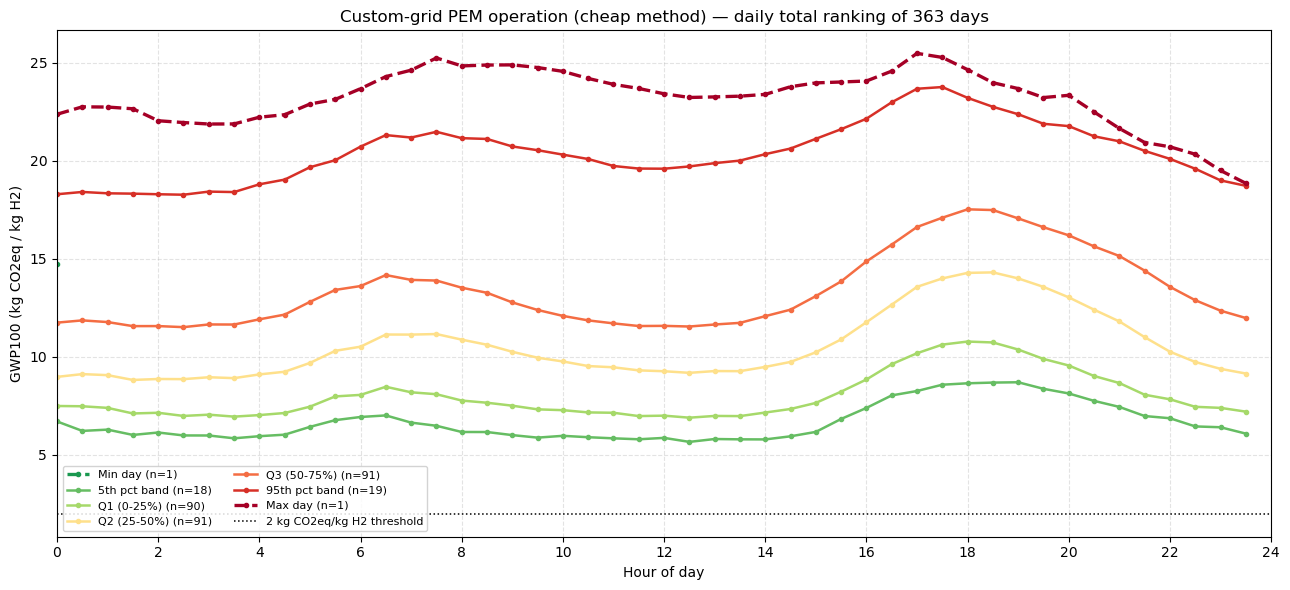

In [6]:
if grid_df_results is None or grid_df_results.empty:
    print("Skipping custom-grid plot — no results loaded.")
else:
    tech_cols = grid_tech_columns(grid_df_results)
    secondary_col, secondary_ylabel = choose_secondary_grid_col(grid_df_results)
    print("Detected custom-grid technology columns:", tech_cols)
    
    if is_year_average_like(grid_df_results, source="grid"):
        # Annual mode: 24-hour cycles by representative period
        plot_data = grid_df_results.copy()
        if "REP_SEASON" in plot_data.columns and "REP_KIND" in plot_data.columns:
            # Combine season + kind to get 12 unique groups (4 seasons × 3 kinds)
            plot_data["rep_label"] = plot_data["REP_SEASON"] + " — " + plot_data["REP_KIND"]
            group_col = "rep_label"
        elif "REP_SEASON" in plot_data.columns:
            group_col = "REP_SEASON"
        else:
            # Fallback: group by date extracted from datetime
            plot_data["date_group"] = pd.to_datetime(plot_data["datetime"], errors="coerce").dt.date
            group_col = "date_group"
        
        # Extract year from data
        year = pd.to_datetime(plot_data["datetime"], errors="coerce").dt.year.iloc[0] if len(plot_data) > 0 else ""
        
        for tech in tech_cols:
            plot_annual_24h_lines(
                plot_data,
                [tech],
                group_col,
                title=f"Custom-grid {tech} — 24-hour cycles ({year})",
                ylabel="GWP100 (kg CO2eq / kg H2)",
                figsize=(13, 6),
            )
    elif count_distinct_days(grid_df_results) >= MIN_DAYS_FOR_BASKETS:
        # Many-day range: collapse the year into min / 5th / Q1 / Q2 / Q3 / 95th / max
        # representative 24-hour profiles (days ranked by daily total GWP100).
        for tech in tech_cols:
            plot_daily_percentile_profiles(
                grid_df_results,
                tech,
                title=f"Custom-grid {tech} ({cfg.METHOD_MODE} method)",
                ylabel="GWP100 (kg CO2eq / kg H2)",
            )
    else:
        # Short range: adaptive time-series plot
        plot_adaptive_lines(
            grid_df_results,
            tech_cols,
            title=f"Custom-grid hydrogen GWP100 ({cfg.METHOD_MODE} method)",
            ylabel="GWP100 (kg CO2eq / kg H2)",
            source="grid",
            secondary_col=secondary_col,
            secondary_ylabel=secondary_ylabel,
            threshold_lines=GWP_THRESHOLDS,
            figsize=(12, 5),
        )


## Plot 2 — wind/grid electrolyser GWP100

This handles `blended`, `switching`, and `both`. For long multi-day ranges, each mode+tech is collapsed into seven representative 24-hour profiles — **min**, **5th percentile band**, **Q1 (0–25%)**, **Q2 (25–50%)**, **Q3 (50–75%)**, **95th percentile band**, **max** — where days are ranked by their daily total GWP100. Min and max are single unchanged days; the bands are the mean half-hourly profile of the days in each range.


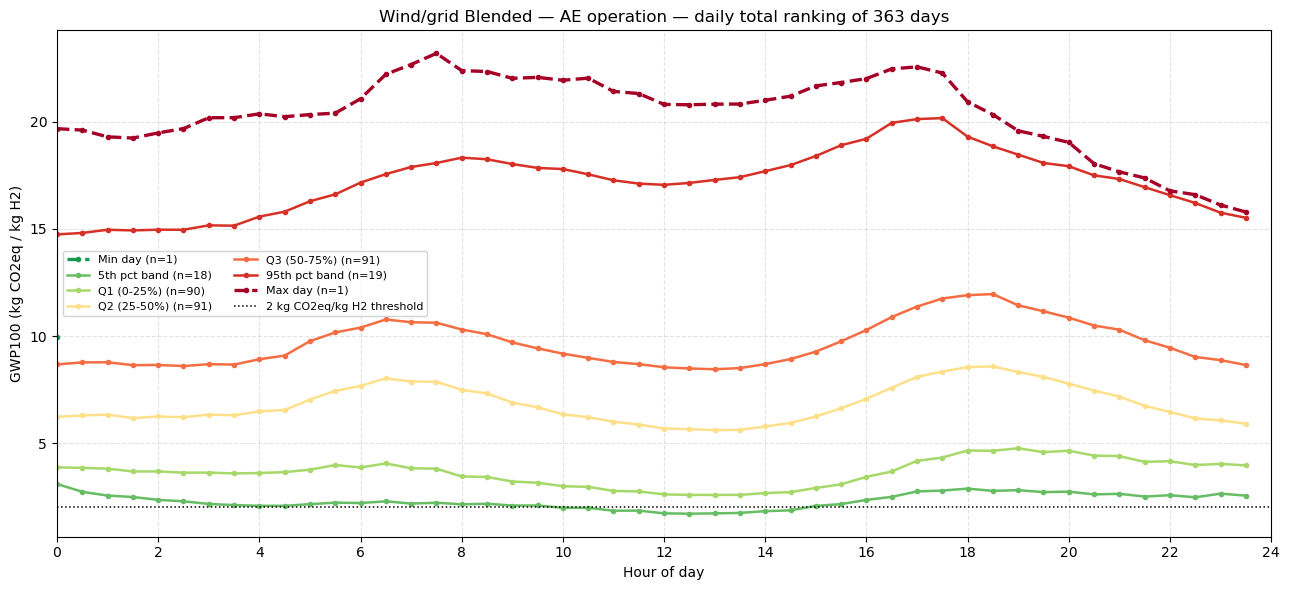

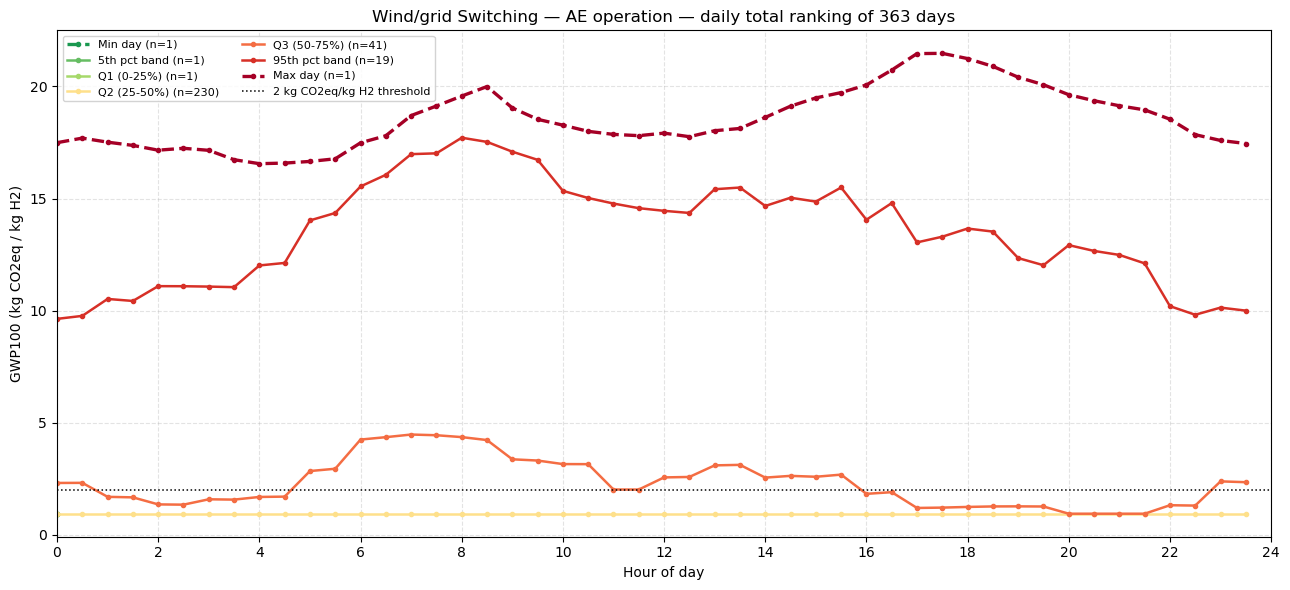

In [7]:
def plot_wind_gwp_adaptive(wind_df: Optional[pd.DataFrame]):
    if wind_df is None or wind_df.empty:
        print("Skipping wind/grid GWP plot — no results loaded.")
        return
    required = {"gwp100_kgco2e_per_kg_h2"}
    if not required.issubset(wind_df.columns):
        print("Skipping wind/grid GWP plot — required GWP column not found.")
        print("Available columns:", list(wind_df.columns))
        return

    data = wind_df.copy()
    if "electrolyser_tech" not in data.columns:
        data["electrolyser_tech"] = "electrolyser"
    if "wind_lca_mode" not in data.columns:
        data["wind_lca_mode"] = getattr(cfg, "WIND_LCA_MODE", "wind_grid")

    is_annual = is_year_average_like(data, source="wind")
    
    if is_annual:
        # Annual mode: 24-hour cycles per mode+tech, grouped by representative period
        # Extract year from data
        year = pd.to_datetime(data["datetime"], errors="coerce").dt.year.iloc[0] if len(data) > 0 else ""
        
        for (mode, tech), tdf in data.groupby(["wind_lca_mode", "electrolyser_tech"]):
            plot_tdf = tdf.copy()
            if "REP_SEASON" in plot_tdf.columns and "REP_KIND" in plot_tdf.columns:
                # Combine season + kind to get 12 unique groups (4 seasons × 3 kinds)
                plot_tdf["rep_label"] = plot_tdf["REP_SEASON"] + " — " + plot_tdf["REP_KIND"]
                group_col = "rep_label"
            elif "REP_SEASON" in plot_tdf.columns:
                group_col = "REP_SEASON"
            else:
                # Fallback: group by date extracted from datetime
                plot_tdf["date_group"] = pd.to_datetime(plot_tdf["datetime"], errors="coerce").dt.date
                group_col = "date_group"
            
            plot_annual_24h_lines(
                plot_tdf,
                ["gwp100_kgco2e_per_kg_h2"],
                group_col,
                title=f"Wind/grid {mode.title()} — {tech} — 24-hour cycles ({year})",
                ylabel="GWP100 (kg CO2eq / kg H2)",
                figsize=(13, 6),
            )
        return

    # Many-day range: collapse each mode+tech into min / 5th / Q1 / Q2 / Q3 / 95th / max
    # representative 24-hour profiles (days ranked by daily total GWP100).
    if count_distinct_days(data) >= MIN_DAYS_FOR_BASKETS:
        for (mode, tech), tdf in data.groupby(["wind_lca_mode", "electrolyser_tech"]):
            plot_daily_percentile_profiles(
                tdf,
                "gwp100_kgco2e_per_kg_h2",
                title=f"Wind/grid {str(mode).title()} — {tech}",
                ylabel="GWP100 (kg CO2eq / kg H2)",
            )
        return

    # Short range: adaptive time-series plot (original logic)
    label_col = "series_label"
    data[label_col] = data["wind_lca_mode"].astype(str) + " — " + data["electrolyser_tech"].astype(str)

    if has_datetime(data):
        wide = data.pivot_table(
            index="datetime",
            columns=label_col,
            values="gwp100_kgco2e_per_kg_h2",
            aggfunc="mean",
        ).reset_index()
        # Preserve representative metadata if available by taking the first row per datetime.
        meta_cols = [c for c in data.columns if c not in ["gwp100_kgco2e_per_kg_h2", label_col] and c not in wide.columns]
        if meta_cols and is_year_average_like(data, source="wind"):
            meta = data.sort_values("datetime").groupby("datetime", as_index=False)[meta_cols].first()
            wide = wide.merge(meta, on="datetime", how="left")
    else:
        data["row_id"] = data.groupby(label_col).cumcount()
        wide = data.pivot_table(
            index="row_id",
            columns=label_col,
            values="gwp100_kgco2e_per_kg_h2",
            aggfunc="mean",
        ).reset_index()

    y_cols = [c for c in wide.columns if c not in {"datetime", "row_id"} and pd.api.types.is_numeric_dtype(wide[c])]
    plot_adaptive_lines(
        wide,
        y_cols,
        title=f"Wind/grid electrolyser GWP100 ({cfg.WIND_LCA_MODE} mode setting)",
        ylabel="GWP100 (kg CO2eq / kg H2)",
        source="wind",
        threshold_lines=GWP_THRESHOLDS,
        figsize=(12, 5),
    )


plot_wind_gwp_adaptive(wind_df_results)


# Plot 3 — wind/grid operating diagnostics

The diagnostic plot changes with the mode:

- For blended operation, it shows wind fraction versus GWP100.
- For switching operation, it shows the **daily share of time running on wind** (% of each day's slices on wind). Daily ticks vary dynamically with the number of days in the run (one tick per day for short ranges, thinned to stay readable for a full year), with month labels shown underneath.


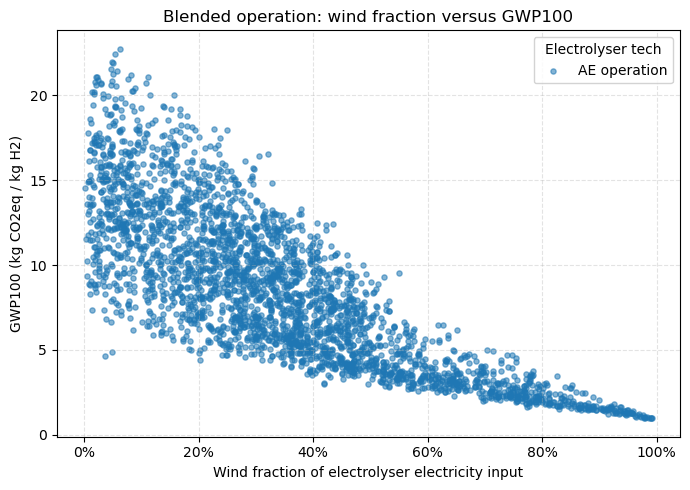

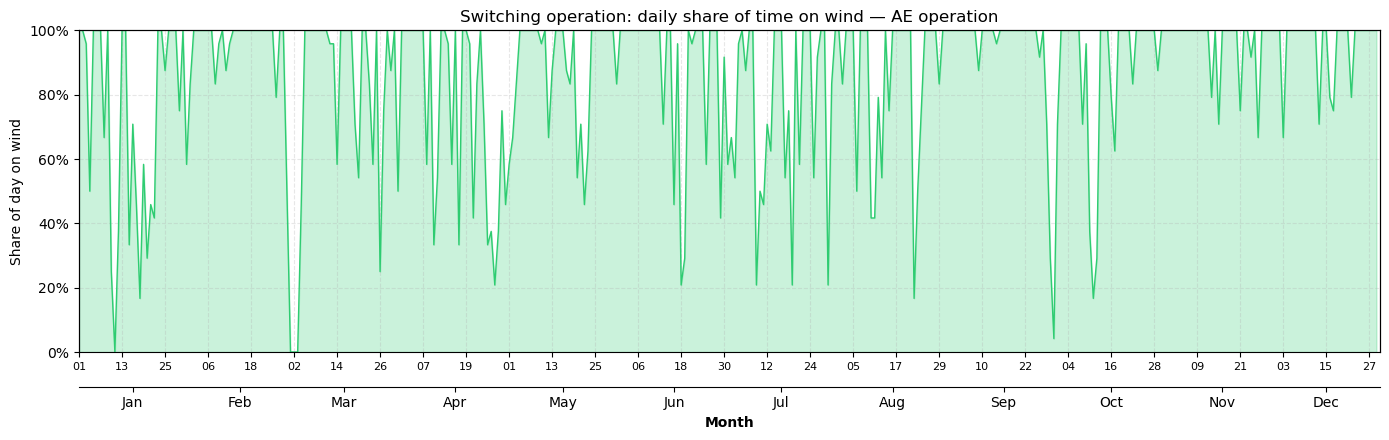

In [18]:
def plot_blended_diagnostic(df: pd.DataFrame):
    if "wind_fraction" not in df.columns or "gwp100_kgco2e_per_kg_h2" not in df.columns:
        return False
    data = df[df["wind_lca_mode"].astype(str).eq("blended")].copy() if "wind_lca_mode" in df.columns else df.copy()
    if data.empty:
        return False
    if "electrolyser_tech" not in data.columns:
        data["electrolyser_tech"] = "electrolyser"

    fig, ax = plt.subplots(figsize=(7, 5))
    for tech, tdf in data.groupby("electrolyser_tech"):
        plot_df = tdf[["wind_fraction", "gwp100_kgco2e_per_kg_h2"]].apply(pd.to_numeric, errors="coerce").dropna()
        if plot_df.empty:
            continue
        # Limit points only for rendering speed/readability; summary stats still use all rows elsewhere.
        if len(plot_df) > 3000:
            plot_df = plot_df.sample(3000, random_state=1).sort_values("wind_fraction")
        ax.scatter(plot_df["wind_fraction"], plot_df["gwp100_kgco2e_per_kg_h2"], alpha=0.55, s=14, label=tech)

    ax.set_title("Blended operation: wind fraction versus GWP100")
    ax.set_xlabel("Wind fraction of electrolyser electricity input")
    ax.set_ylabel("GWP100 (kg CO2eq / kg H2)")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(title="Electrolyser tech", framealpha=0.85)
    plt.tight_layout()
    plt.show()
    return True


def plot_switching_diagnostic(df: pd.DataFrame):
    if "electricity_source" not in df.columns:
        return False
    data = df[df["wind_lca_mode"].astype(str).eq("switching")].copy() if "wind_lca_mode" in df.columns else df.copy()
    if data.empty:
        return False
    if "electrolyser_tech" not in data.columns:
        data["electrolyser_tech"] = "electrolyser"

    # Use the first tech for a clean source-sequence diagnostic.
    first_tech = list(data["electrolyser_tech"].dropna().unique())[0]
    src = data[data["electrolyser_tech"] == first_tech].copy()

    if has_datetime(src) and not is_year_average_like(src, source="wind"):
        src["datetime"] = as_datetime_series(src)
        src = src.dropna(subset=["datetime"]).sort_values("datetime")

        # Daily share of slices running on wind (0-1).
        is_wind = src["electricity_source"].astype(str).str.lower().eq("wind")
        daily = (
            is_wind.groupby(src["datetime"].dt.normalize())
                   .mean()
                   .sort_index()
        )
        if daily.empty:
            return False
        day_dates = pd.Series(daily.index)

        fig, ax = plt.subplots(figsize=(14, 4.5))
        ax.plot(daily.index, daily.values, linewidth=1.0, color="#2ecc71")
        ax.fill_between(daily.index, daily.values, alpha=0.25, color="#2ecc71")
        # Per-day markers only stay readable for short runs.
        if len(daily) <= 120:
            ax.scatter(daily.index, daily.values, s=12, color="#27ae60")
        ax.set_title(f"Switching operation: daily share of time on wind — {first_tech}")
        ax.set_ylabel("Share of day on wind")
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
        ax.grid(True, linestyle="--", alpha=0.3)

        # Dynamic daily ticks: one tick per day, thinned so labels stay readable.
        # The tick rate varies with the number of distinct days in the run
        # (e.g. ~365 days -> a tick roughly every 2 weeks).
        n_days = len(day_dates)
        max_day_ticks = 31  # cap labelled day ticks so a full year stays readable
        step = max(1, int(np.ceil(n_days / max_day_ticks)))
        tick_dates = day_dates.iloc[::step]
        ax.set_xticks(list(tick_dates))
        ax.set_xticklabels([d.strftime("%d") for d in tick_dates], rotation=0, fontsize=8)
        ax.set_xlim(day_dates.iloc[0], day_dates.iloc[-1] + pd.Timedelta(days=1))

        # Month labels underneath via a secondary axis, centred on each month's days.
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        multi_year = day_dates.dt.year.nunique() > 1
        month_periods = day_dates.dt.to_period("M")
        month_mids = []
        month_labels_list = []
        for _, grp in day_dates.groupby(month_periods):
            grp = grp.reset_index(drop=True)
            mid = grp.iloc[len(grp) // 2]
            month_mids.append(mid)
            month_labels_list.append(mid.strftime("%b %Y") if multi_year else mid.strftime("%b"))
        if month_mids:
            ax2.set_xticks(month_mids)
            ax2.set_xticklabels(month_labels_list, fontsize=9, fontweight="bold")
        ax2.xaxis.set_ticks_position("bottom")
        ax2.xaxis.set_label_position("bottom")
        ax2.spines["bottom"].set_position(("outward", 25))
        ax2.set_xlabel("Month", fontweight="bold")

        plt.tight_layout()
        plt.show()
        return True

    # Categorical fallback for year_average or no datetime.
    labels = representative_labels(src)
    y = src["electricity_source"].astype(str).str.lower().map({"grid": 0, "wind": 1})
    fig, ax = plt.subplots(figsize=(12, 3.2))
    ax.plot(np.arange(len(src)), y, marker="o", linewidth=1.2)
    ax.set_title(f"Switching operation: electricity source by representative period — {first_tech}")
    ax.set_xlabel("Representative period")
    ax.set_ylabel("Source")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["grid", "wind"])
    ax.set_xticks(np.arange(len(src)))
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.grid(True, axis="x", linestyle="--", alpha=0.25)
    plt.tight_layout()
    plt.show()
    return True


if wind_df_results is None or wind_df_results.empty:
    print("Skipping wind/grid diagnostics — no results loaded.")
else:
    shown_any = False
    shown_any = plot_blended_diagnostic(wind_df_results) or shown_any
    shown_any = plot_switching_diagnostic(wind_df_results) or shown_any
    if not shown_any:
        print("No wind/grid diagnostic columns found. Available columns:")
        print(list(wind_df_results.columns))


## Plot 4 — duration curves

Duration curves are useful for threshold questions such as: “what fraction of operation is below 2 kg CO₂eq/kg H₂?” They work for any time range, including a full year.


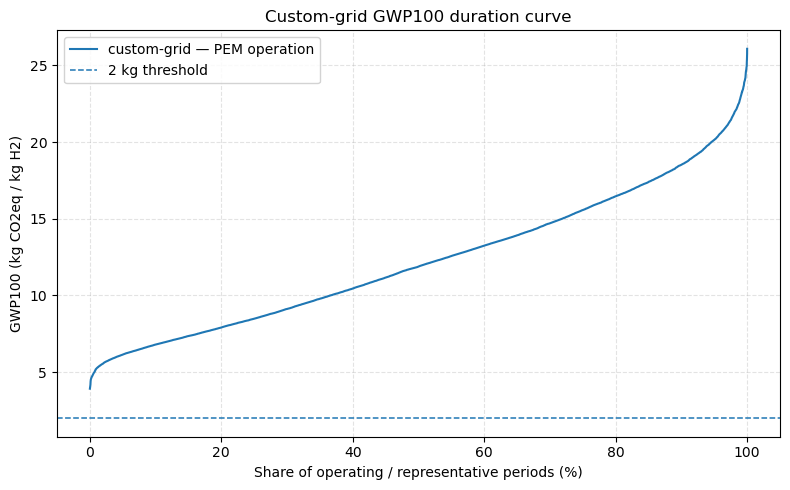

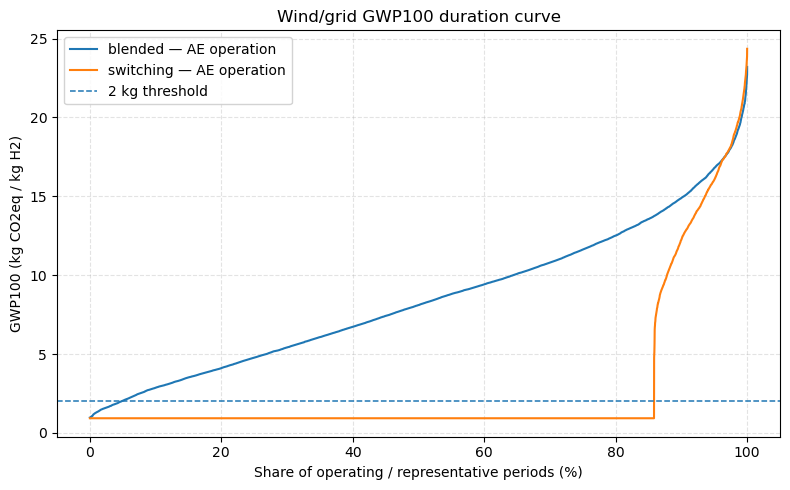

In [10]:
def plot_duration_curves_from_grid(df: Optional[pd.DataFrame]):
    if df is None or df.empty:
        return False
    tech_cols = grid_tech_columns(df)
    if not tech_cols:
        return False
    fig, ax = plt.subplots(figsize=(8, 5))
    for col in tech_cols:
        pct, values = duration_curve(df[col])
        if len(values):
            ax.plot(pct, values, label=f"custom-grid — {col}")
    for threshold in GWP_THRESHOLDS:
        ax.axhline(threshold, linestyle="--", linewidth=1.1, label=f"{threshold:g} kg threshold")
    ax.set_title("Custom-grid GWP100 duration curve")
    ax.set_xlabel("Share of operating / representative periods (%)")
    ax.set_ylabel("GWP100 (kg CO2eq / kg H2)")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(framealpha=0.85)
    plt.tight_layout()
    plt.show()
    return True


def plot_duration_curves_from_wind(df: Optional[pd.DataFrame]):
    if df is None or df.empty or "gwp100_kgco2e_per_kg_h2" not in df.columns:
        return False
    data = df.copy()
    if "electrolyser_tech" not in data.columns:
        data["electrolyser_tech"] = "electrolyser"
    if "wind_lca_mode" not in data.columns:
        data["wind_lca_mode"] = getattr(cfg, "WIND_LCA_MODE", "wind_grid")

    fig, ax = plt.subplots(figsize=(8, 5))
    for (mode, tech), tdf in data.groupby(["wind_lca_mode", "electrolyser_tech"]):
        pct, values = duration_curve(tdf["gwp100_kgco2e_per_kg_h2"])
        if len(values):
            ax.plot(pct, values, label=f"{mode} — {tech}")
    for threshold in GWP_THRESHOLDS:
        ax.axhline(threshold, linestyle="--", linewidth=1.1, label=f"{threshold:g} kg threshold")
    ax.set_title("Wind/grid GWP100 duration curve")
    ax.set_xlabel("Share of operating / representative periods (%)")
    ax.set_ylabel("GWP100 (kg CO2eq / kg H2)")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(framealpha=0.85)
    plt.tight_layout()
    plt.show()
    return True

shown = False
shown = plot_duration_curves_from_grid(grid_df_results) or shown
shown = plot_duration_curves_from_wind(wind_df_results) or shown
if not shown:
    print("No data available for duration curves.")


## Optional full-range heatmap

This is only useful when you have real datetime slices across many days. It is skipped automatically for `single`, very short ranges, and `year_average` representative-day outputs.


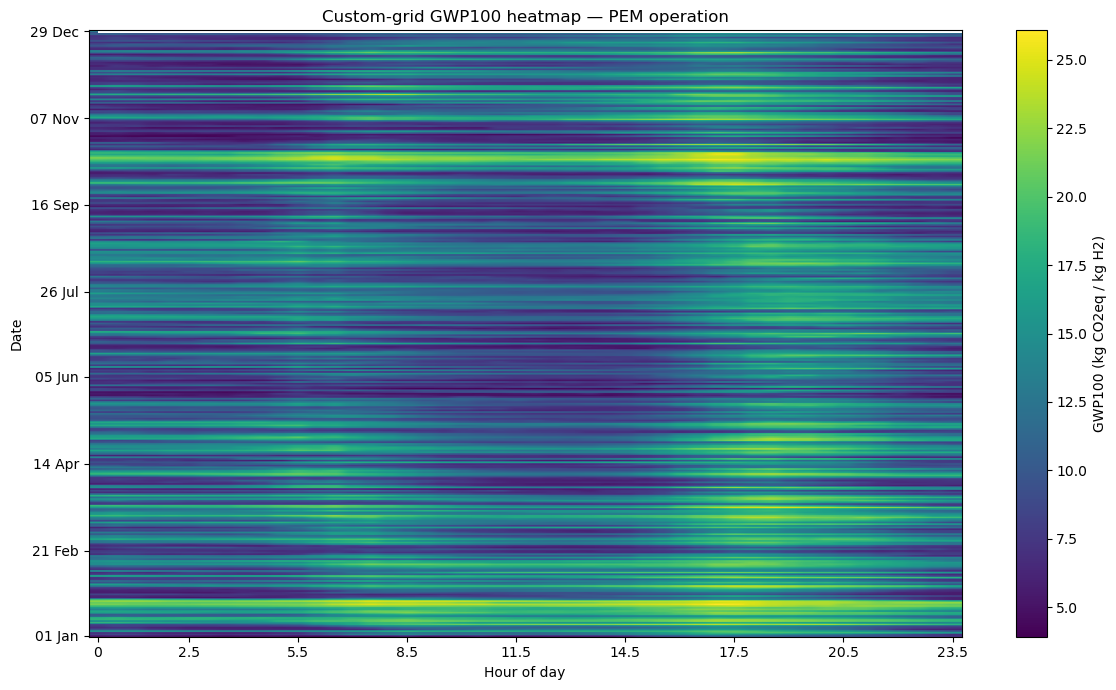

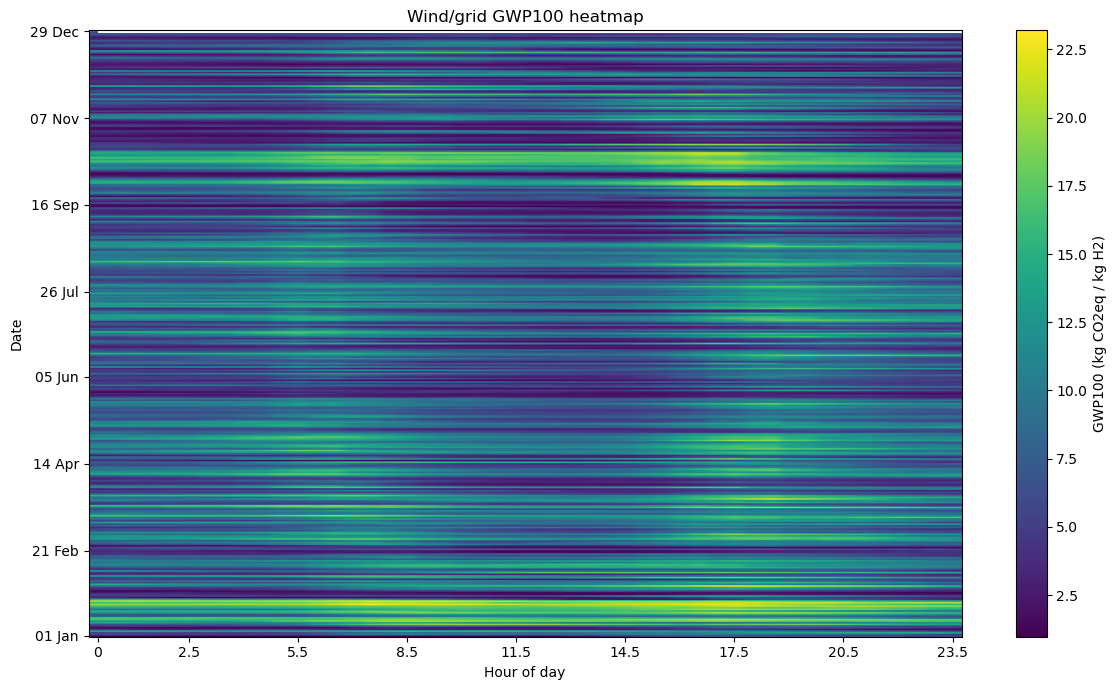

In [11]:
def plot_timeslice_heatmap(df: Optional[pd.DataFrame], value_col: str, *, title: str):
    if df is None or df.empty or value_col not in df.columns or not has_datetime(df):
        return False
    if is_year_average_like(df, source="wind") or is_year_average_like(df, source="grid"):
        print(f"Skipping heatmap for {title} — representative-period output is better shown categorically.")
        return False

    data = df[["datetime", value_col]].copy()
    data["datetime"] = as_datetime_series(data)
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")
    data = data.dropna().sort_values("datetime")
    if data.empty:
        return False
    span = data["datetime"].max() - data["datetime"].min()
    if span < pd.Timedelta(days=5):
        print(f"Skipping heatmap for {title} — range is short; line plot is clearer.")
        return False

    data["date"] = data["datetime"].dt.date
    data["slot"] = data["datetime"].dt.hour + data["datetime"].dt.minute / 60.0
    heatmap_data = data.pivot_table(index="date", columns="slot", values=value_col, aggfunc="mean")
    if heatmap_data.shape[0] < 5 or heatmap_data.shape[1] < 2:
        return False

    fig, ax = plt.subplots(figsize=(12, 7))
    im = ax.imshow(heatmap_data.to_numpy(), aspect="auto", origin="lower")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("GWP100 (kg CO2eq / kg H2)")

    # x ticks: hours only, no overcrowding.
    slots = np.array(heatmap_data.columns, dtype=float)
    tick_idx = np.linspace(0, len(slots) - 1, min(9, len(slots))).astype(int)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([f"{slots[i]:g}" for i in tick_idx])

    # y ticks: about 8 evenly spaced dates.
    dates = list(heatmap_data.index)
    y_idx = np.linspace(0, len(dates) - 1, min(8, len(dates))).astype(int)
    ax.set_yticks(y_idx)
    ax.set_yticklabels([pd.to_datetime(dates[i]).strftime("%d %b") for i in y_idx])

    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Date")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return True

shown = False
if grid_df_results is not None and not grid_df_results.empty:
    tech_cols = grid_tech_columns(grid_df_results)
    if tech_cols:
        shown = plot_timeslice_heatmap(
            grid_df_results.reset_index(drop=True),
            tech_cols[0],
            title=f"Custom-grid GWP100 heatmap — {tech_cols[0]}",
        ) or shown

if wind_df_results is not None and not wind_df_results.empty and "gwp100_kgco2e_per_kg_h2" in wind_df_results.columns:
    tmp = wind_df_results.copy()
    if "electrolyser_tech" in tmp.columns:
        tmp = tmp[tmp["electrolyser_tech"] == tmp["electrolyser_tech"].dropna().iloc[0]]
    if "wind_lca_mode" in tmp.columns:
        tmp = tmp[tmp["wind_lca_mode"] == tmp["wind_lca_mode"].dropna().iloc[0]]
    shown = plot_timeslice_heatmap(
        tmp,
        "gwp100_kgco2e_per_kg_h2",
        title="Wind/grid GWP100 heatmap",
    ) or shown

if not shown:
    print("No suitable long datetime range found for a heatmap.")


## Combined summary table

The summary includes mean/min/max and threshold shares. This is usually the cleanest place to report “below 2 kg CO₂eq/kg H₂ for X% of periods.”


In [12]:
def threshold_share(series: pd.Series, threshold: float) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    return 100.0 * float((s <= threshold).mean())

rows = []

if grid_df_results is not None and not grid_df_results.empty:
    for tech in grid_tech_columns(grid_df_results):
        s = pd.to_numeric(grid_df_results[tech], errors="coerce").dropna()
        if s.empty:
            continue
        row = {
            "source": "custom_grid",
            "mode": cfg.METHOD_MODE,
            "time_mode": cfg.GRID_TIME_MODE,
            "technology": tech,
            "n_periods": int(s.notna().sum()),
            "mean_gwp100": s.mean(),
            "median_gwp100": s.median(),
            "p10_gwp100": s.quantile(0.10),
            "p90_gwp100": s.quantile(0.90),
            "min_gwp100": s.min(),
            "max_gwp100": s.max(),
        }
        for threshold in GWP_THRESHOLDS:
            row[f"share_below_{threshold:g}kg_%"] = threshold_share(s, threshold)
        rows.append(row)

if wind_df_results is not None and not wind_df_results.empty and "gwp100_kgco2e_per_kg_h2" in wind_df_results.columns:
    data = wind_df_results.copy()
    if "electrolyser_tech" not in data.columns:
        data["electrolyser_tech"] = "electrolyser"
    if "wind_lca_mode" not in data.columns:
        data["wind_lca_mode"] = getattr(cfg, "WIND_LCA_MODE", "wind_grid")

    for (mode, tech), tdf in data.groupby(["wind_lca_mode", "electrolyser_tech"]):
        s = pd.to_numeric(tdf["gwp100_kgco2e_per_kg_h2"], errors="coerce").dropna()
        if s.empty:
            continue
        row = {
            "source": "wind_grid",
            "mode": mode,
            "time_mode": cfg.GRID_TIME_MODE,
            "technology": tech,
            "n_periods": int(s.notna().sum()),
            "mean_gwp100": s.mean(),
            "median_gwp100": s.median(),
            "p10_gwp100": s.quantile(0.10),
            "p90_gwp100": s.quantile(0.90),
            "min_gwp100": s.min(),
            "max_gwp100": s.max(),
        }
        for threshold in GWP_THRESHOLDS:
            row[f"share_below_{threshold:g}kg_%"] = threshold_share(s, threshold)
        rows.append(row)

if rows:
    summary = pd.DataFrame(rows).set_index(["source", "mode", "time_mode", "technology"]).sort_index()
    display(summary.round(3))
else:
    print("No results to summarise. Run the building-block notebooks first.")


n_periods  mean_gwp100  \
source      mode      time_mode technology                              
custom_grid cheap     range     PEM operation      17377       12.289   
wind_grid   blended   range     AE operation       17377        8.504   
            switching range     AE operation       17377        2.858   

                                               median_gwp100  p10_gwp100  \
source      mode      time_mode technology                                 
custom_grid cheap     range     PEM operation         11.886       6.802   
wind_grid   blended   range     AE operation           8.106       2.873   
            switching range     AE operation           0.932       0.932   

                                               p90_gwp100  min_gwp100  \
source      mode      time_mode technology                              
custom_grid cheap     range     PEM operation      18.520       3.925   
wind_grid   blended   range     AE operation       14.896       0.974   
            switching range     AE operation       12.261       0.932   

                                               max_gwp100  share_below_2kg_%  
source      mode      time_mode technology                                    
custom_grid cheap     range     PEM operation      26.076              0.000  
wind_grid   blended   range     AE operation       23.201              4.776  
            switching range     AE operation       24.350             85.832

## Electricity generation mix for the year

This pie chart shows the composition of electricity generation sources for the analysis year, with renewable sources in shades of green and non-renewable sources in shades of grey.



UK Electricity Generation Mix — 2025


,Source,Total (MWh),Percentage,Category
0,GAS,"154,612,298",32.3%,Fossil fuel
1,WIND,"137,504,694",28.7%,Low-carbon
2,NUCLEAR,"68,306,585",14.3%,Low-carbon
3,BIOMASS,"39,866,002",8.3%,Low-carbon
4,SOLAR,"37,321,496",7.8%,Low-carbon
5,WIND_EMB,"34,186,666",7.1%,Low-carbon
6,HYDRO,"6,731,806",1.4%,Low-carbon
7,COAL,246,0.0%,Fossil fuel



Total Generation: 478,529,793 MWh



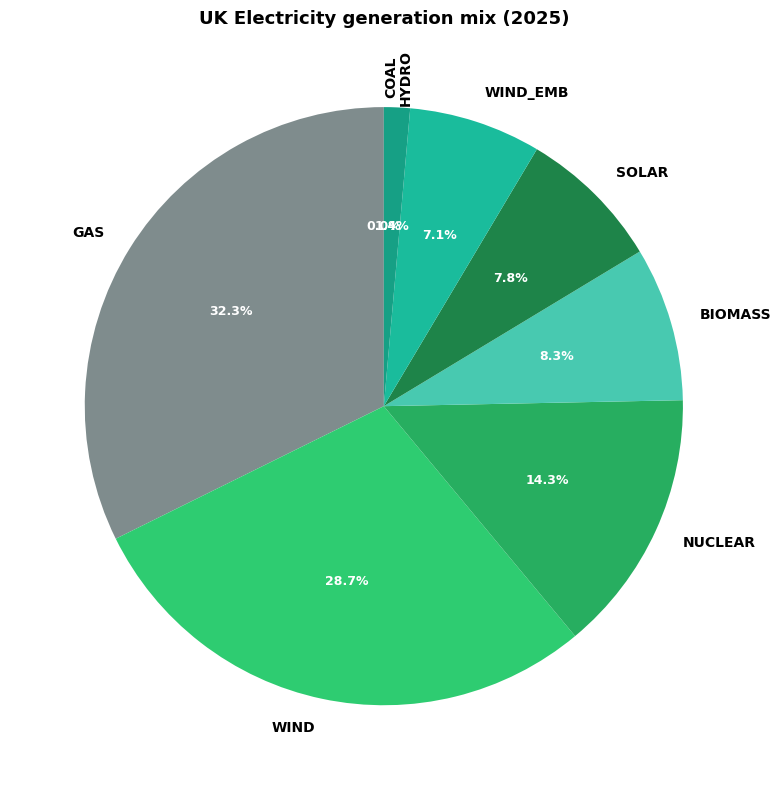

In [13]:
def plot_generation_mix_from_neso():
    """Plot pie chart of electricity generation mix from NESO CSV for the analysis year.
    Shows individual generation sources with color shading by category (green/grey).
    """
    # Read the NESO CSV file
    neso_path = Path(cfg.CSV_PATH)
    if not neso_path.exists():
        print(f"NESO file not found: {neso_path}")
        return False
    
    try:
        df = pd.read_csv(neso_path)
    except Exception as e:
        print(f"Error reading NESO CSV: {e}")
        return False
    
    if df.empty:
        print("NESO CSV is empty")
        return False
    
    # Find datetime column
    dt_col = None
    for candidate in ["DATETIME", "datetime", "Date", "date", "TIMESTAMP", "timestamp"]:
        if candidate in df.columns:
            dt_col = candidate
            break
    
    if dt_col is None:
        print("No datetime column found in NESO CSV")
        return False
    
    # Parse datetime and filter by year from config
    df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce")
    analysis_year = cfg.GRID_YEAR
    df_year = df[df[dt_col].dt.year == analysis_year].copy()
    
    if df_year.empty:
        print(f"No data found for year {analysis_year} in NESO CSV")
        print(f"Available years: {df[dt_col].dt.year.unique()}")
        return False
    
    # Define generation source columns with colors
    # Green sources (different shades of green)
    green_sources = {
        "NUCLEAR": "#27ae60",      # dark green
        "WIND": "#2ecc71",         # medium green
        "WIND_EMB": "#1abc9c",     # teal green
        "HYDRO": "#16a085",        # darker teal
        "BIOMASS": "#48c9b0",      # light teal
        "SOLAR": "#1e8449",        # forest green
    }
    # Grey sources (different shades of grey)
    grey_sources = {
        "GAS": "#7f8c8d",          # light grey
        "COAL": "#34495e",         # dark grey
    }
    
    # Collect totals for each source
    source_totals = {}
    source_colors = {}
    source_categories = {}
    
    for source, color in green_sources.items():
        if source in df_year.columns:
            total = pd.to_numeric(df_year[source], errors="coerce").sum()
            if pd.notna(total) and total > 0:
                source_totals[source] = total
                source_colors[source] = color
                source_categories[source] = "Low-carbon"
    
    for source, color in grey_sources.items():
        if source in df_year.columns:
            total = pd.to_numeric(df_year[source], errors="coerce").sum()
            if pd.notna(total) and total > 0:
                source_totals[source] = total
                source_colors[source] = color
                source_categories[source] = "Fossil fuel"
    
    if not source_totals:
        print("No generation data found for the specified sources")
        return False
    
    # Sort by total (largest first)
    source_totals = dict(sorted(source_totals.items(), key=lambda x: x[1], reverse=True))
    
    # Create pie data
    values = list(source_totals.values())
    labels = list(source_totals.keys())
    colors = [source_colors[label] for label in labels]
    
    # Calculate total and percentages
    total_gen = sum(source_totals.values())
    percentages = {k: 100.0 * v / total_gen for k, v in source_totals.items()}
    
    # Create statistics table
    stats_rows = []
    for source in labels:
        stats_rows.append({
            "Source": source,
            "Total (MWh)": f"{source_totals[source]:,.0f}",
            "Percentage": f"{percentages[source]:.1f}%",
            "Category": source_categories[source],
        })
    
    stats_df = pd.DataFrame(stats_rows)
    
    # Print overview statistics
    print(f"\n{'='*70}")
    print(f"UK Electricity Generation Mix — {analysis_year}")
    print(f"{'='*70}")
    display(stats_df)
    print(f"\nTotal Generation: {total_gen:,.0f} MWh")
    print(f"{'='*70}\n")
    
    # Create pie chart
    fig, ax = plt.subplots(figsize=(11, 8))
    wedges, texts, autotexts = ax.pie(
        values,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        textprops={"fontsize": 10}
    )
    
    # Make percentage text more readable
    for autotext in autotexts:
        autotext.set_color("white")
        autotext.set_fontweight("bold")
        autotext.set_fontsize(9)
    
    # Make labels bold and readable
    for text in texts:
        text.set_fontweight("bold")
        text.set_fontsize(10)
        # Rotate COAL and HYDRO labels 90 degrees
        if text.get_text() in ["COAL", "HYDRO"]:
            text.set_rotation(90)
    
    ax.set_title(f"UK Electricity generation mix ({analysis_year})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    return True

# Plot generation mix pie chart from NESO data
if not plot_generation_mix_from_neso():
    print("Could not generate electricity mix pie chart.")


## Result distributions & statistics

For each result set (custom grid, blended, switching) this section shows the
**distribution of GWP100** with a fitted normal curve, a **summary-statistics
table** (mean, median, std, IQR, percentiles), and **breakdowns by month and by
season**. Works for any date range and for `year_average` mode.


C:\Users\ls1524\AppData\Local\Temp\ipykernel_33932\3347441401.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_m.boxplot(groups, labels=names, showmeans=True)
C:\Users\ls1524\AppData\Local\Temp\ipykernel_33932\3347441401.py:139: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_s.boxplot(groups, labels=present, showmeans=True)


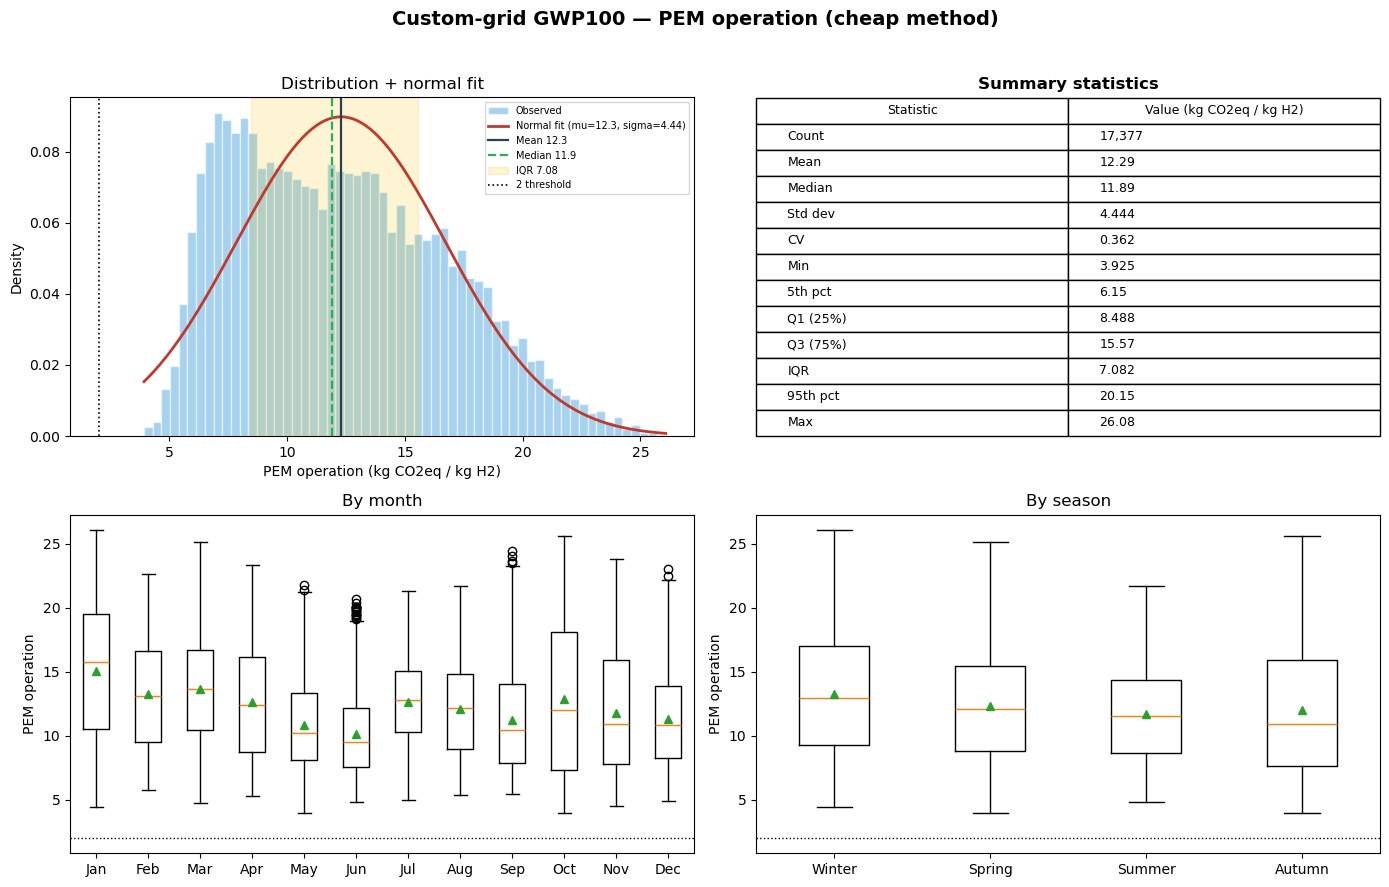


Custom-grid GWP100 — PEM operation (cheap method) — monthly breakdown


,n,mean,median,std,q1,q3,iqr,min,max
Month,,,,,,,,,
Jan,1488,15.0652,15.7419,5.4796,10.5249,19.5060,8.9812,4.4378,26.0759
Feb,1344,13.2156,13.1312,4.1913,9.4973,16.5980,7.1007,5.7257,22.6322
Mar,1488,13.6073,13.6320,4.1375,10.4654,16.6644,6.1991,4.7103,25.1074
Apr,1440,12.5967,12.3672,4.3028,8.7173,16.1628,7.4456,5.2802,23.3366
May,1488,10.8235,10.2203,3.6656,8.0687,13.3538,5.2851,3.9255,21.7827
Jun,1440,10.1318,9.5275,3.3358,7.5819,12.1863,4.6045,4.7846,20.6766
Jul,1488,12.6539,12.7649,3.3230,10.3190,15.0361,4.7171,4.9906,21.2937
Aug,1488,12.1170,12.1882,3.6028,8.9358,14.8438,5.9081,5.3703,21.7184
Sep,1440,11.2170,10.4097,4.0186,7.8297,14.0411,6.2115,5.4359,24.4276


Custom-grid GWP100 — PEM operation (cheap method) — seasonal breakdown


,n,mean,median,std,q1,q3,iqr,min,max
Season,,,,,,,,,
Winter,4177,13.2470,12.9025,4.8105,9.2294,17.0315,7.8021,4.4378,26.0759
Spring,4416,12.3397,12.1073,4.2028,8.7658,15.4657,6.6999,3.9255,25.1074
Summer,4416,11.6506,11.5646,3.5892,8.6205,14.3228,5.7023,4.7846,21.7184
Autumn,4368,11.9667,10.9313,4.9151,7.6567,15.9291,8.2724,3.9824,25.6368


C:\Users\ls1524\AppData\Local\Temp\ipykernel_33932\3347441401.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_m.boxplot(groups, labels=names, showmeans=True)
C:\Users\ls1524\AppData\Local\Temp\ipykernel_33932\3347441401.py:139: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_s.boxplot(groups, labels=present, showmeans=True)


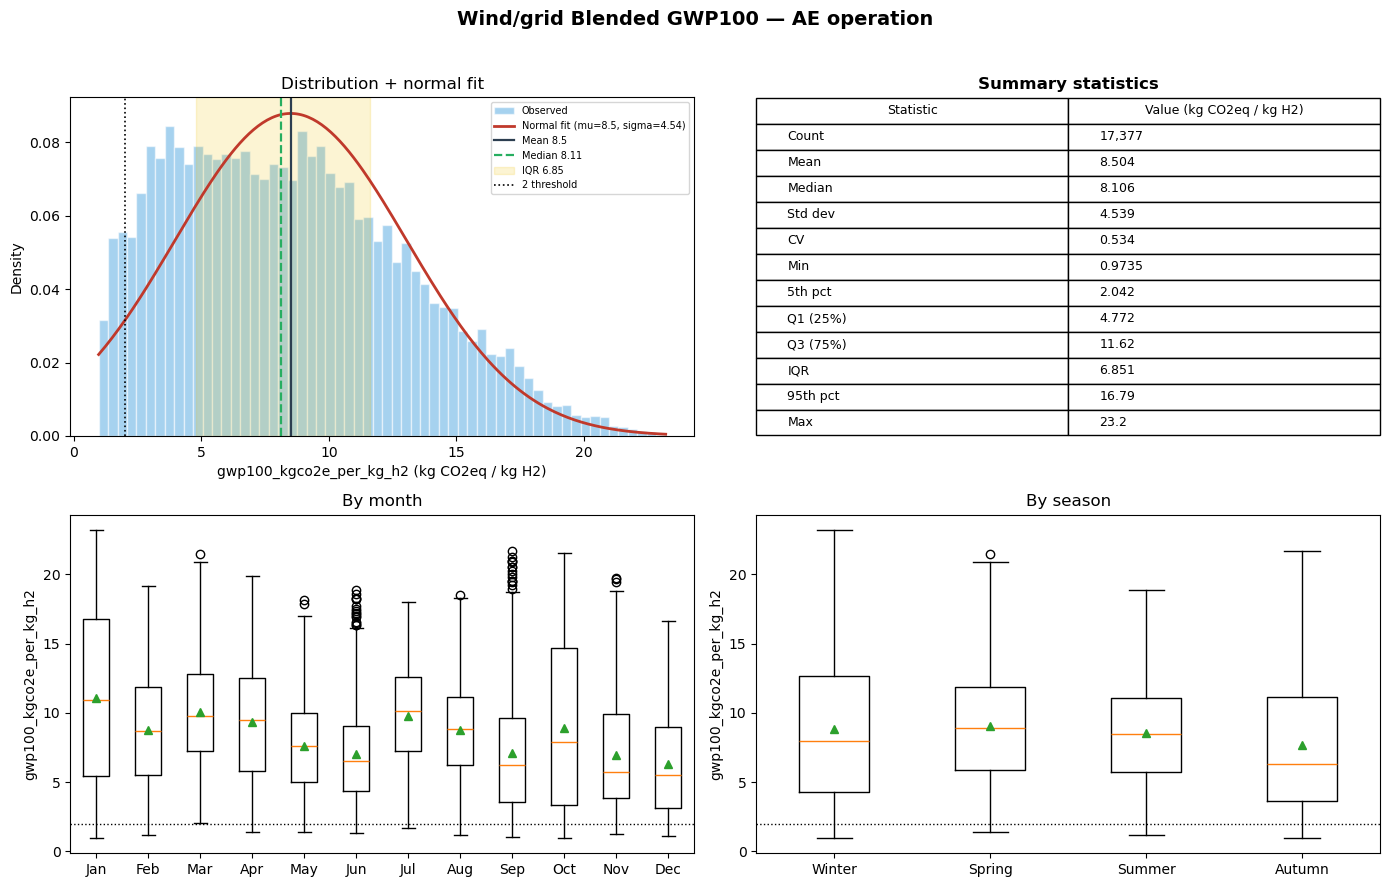


Wind/grid Blended GWP100 — AE operation — monthly breakdown


,n,mean,median,std,q1,q3,iqr,min,max
Month,,,,,,,,,
Jan,1488,11.1055,10.9138,6.4131,5.4200,16.7902,11.3702,0.9735,23.2009
Feb,1344,8.7591,8.6818,4.2037,5.5151,11.8592,6.3441,1.2046,19.1377
Mar,1488,10.0625,9.8038,3.9219,7.2486,12.7999,5.5513,2.0581,21.4814
Apr,1440,9.3777,9.4933,4.1795,5.7742,12.5346,6.7604,1.4246,19.8995
May,1488,7.6245,7.6144,3.3294,4.9902,10.0179,5.0277,1.3695,18.1746
Jun,1440,7.0094,6.4912,3.3955,4.3389,9.0754,4.7365,1.2937,18.8564
Jul,1488,9.7986,10.1091,3.5561,7.2479,12.5763,5.3283,1.7030,18.0323
Aug,1488,8.7422,8.8397,3.4651,6.2722,11.1210,4.8487,1.1766,18.5433
Sep,1440,7.0721,6.2624,4.2974,3.5610,9.6641,6.1031,1.0388,21.6993


Wind/grid Blended GWP100 — AE operation — seasonal breakdown


,n,mean,median,std,q1,q3,iqr,min,max
Season,,,,,,,,,
Winter,4177,8.8037,7.9377,5.3621,4.3214,12.6884,8.3670,0.9735,23.2009
Spring,4416,9.0177,8.9043,3.9588,5.8568,11.8724,6.0156,1.3695,21.4814
Summer,4416,8.5331,8.4918,3.6569,5.7163,11.0922,5.3758,1.1766,18.8564
Autumn,4368,7.6705,6.2798,4.9054,3.6099,11.1160,7.5061,0.9783,21.6993


C:\Users\ls1524\AppData\Local\Temp\ipykernel_33932\3347441401.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_m.boxplot(groups, labels=names, showmeans=True)
C:\Users\ls1524\AppData\Local\Temp\ipykernel_33932\3347441401.py:139: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_s.boxplot(groups, labels=present, showmeans=True)


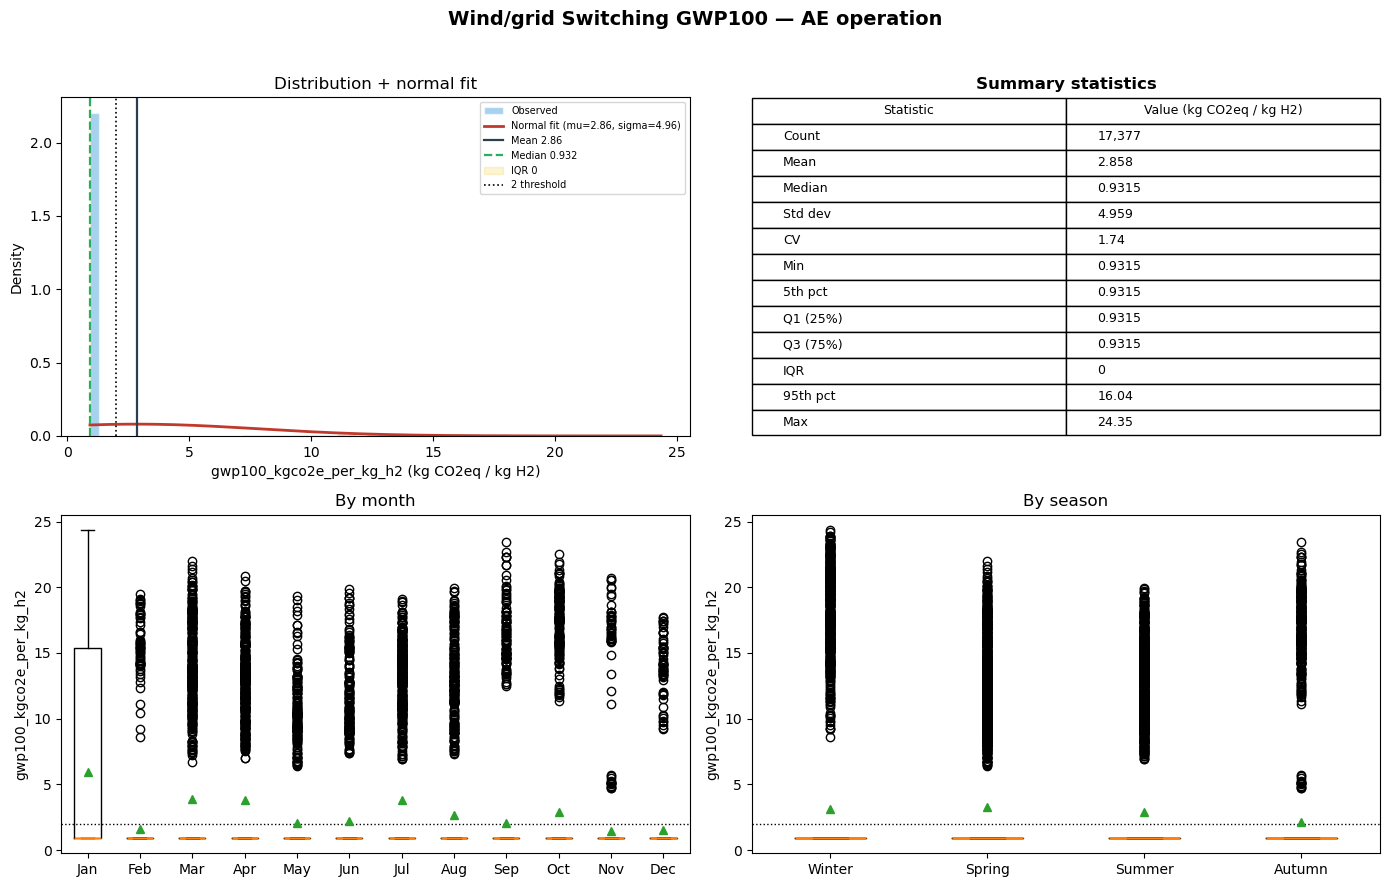


Wind/grid Switching GWP100 — AE operation — monthly breakdown


,n,mean,median,std,q1,q3,iqr,min,max
Month,,,,,,,,,
Jan,1488,5.9176,0.9315,8.1731,0.9315,15.3850,14.4534,0.9315,24.3502
Feb,1344,1.5806,0.9315,3.0447,0.9315,0.9315,0.0000,0.9315,19.4611
Mar,1488,3.9215,0.9315,5.7627,0.9315,0.9315,0.0000,0.9315,21.9867
Apr,1440,3.8356,0.9315,5.3488,0.9315,0.9315,0.0000,0.9315,20.8624
May,1488,2.0498,0.9315,3.2459,0.9315,0.9315,0.0000,0.9315,19.3682
Jun,1440,2.2303,0.9315,3.7314,0.9315,0.9315,0.0000,0.9315,19.8293
Jul,1488,3.8276,0.9315,5.3729,0.9315,0.9315,0.0000,0.9315,19.0879
Aug,1488,2.6953,0.9315,4.4434,0.9315,0.9315,0.0000,0.9315,19.9258
Sep,1440,2.0798,0.9315,4.1304,0.9315,0.9315,0.0000,0.9315,23.4275


Wind/grid Switching GWP100 — AE operation — seasonal breakdown


,n,mean,median,std,q1,q3,iqr,min,max
Season,,,,,,,,,
Winter,4177,3.1110,0.9315,5.7996,0.9315,0.9315,0.0,0.9315,24.3502
Spring,4416,3.2628,0.9315,4.9807,0.9315,0.9315,0.0,0.9315,21.9867
Summer,4416,2.9252,0.9315,4.6218,0.9315,0.9315,0.0,0.9315,19.9258
Autumn,4368,2.1396,0.9315,4.2733,0.9315,0.9315,0.0,0.9315,23.4275


In [14]:
_SEASON_BY_MONTH = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
}
_SEASON_ORDER = ["Winter", "Spring", "Summer", "Autumn"]


def summarise_distribution(series: pd.Series) -> Optional[dict]:
    """Return mean/median/std/IQR/percentile stats for a numeric series."""
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return None
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    mean = s.mean()
    return {
        "n": int(s.size), "mean": mean, "median": s.median(), "std": s.std(ddof=1),
        "min": s.min(), "p05": s.quantile(0.05), "q1": q1, "q3": q3,
        "p95": s.quantile(0.95), "max": s.max(), "iqr": q3 - q1,
        "cv": (s.std(ddof=1) / mean) if mean else np.nan,
    }


def _breakdown_table(data: pd.DataFrame, by: str, value_col: str) -> pd.DataFrame:
    g = data.groupby(by)[value_col]
    out = g.agg(n="count", mean="mean", median="median", std="std", min="min", max="max")
    out["q1"] = g.quantile(0.25)
    out["q3"] = g.quantile(0.75)
    out["iqr"] = out["q3"] - out["q1"]
    return out[["n", "mean", "median", "std", "q1", "q3", "iqr", "min", "max"]]


def analyse_result_distribution(
    df: Optional[pd.DataFrame],
    value_col: str,
    *,
    title: str,
    unit: str = "kg CO2eq / kg H2",
    thresholds: Sequence[float] = GWP_THRESHOLDS,
):
    """Distribution + normal fit + stats + month/season breakdowns.

    Works for any date range and for year_average mode (both retain `datetime`).
    """
    if df is None or len(df) == 0 or value_col not in df.columns:
        print(f"Skipping distribution: {title} — no data / column '{value_col}' missing.")
        return None

    data = df.copy()
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")
    s = data[value_col].dropna()
    if s.empty:
        print(f"Skipping distribution: {title} — no numeric values.")
        return None

    st = summarise_distribution(s)

    # Derive month + season (prefer existing season metadata, else from datetime).
    has_dt = has_datetime(data)
    if has_dt:
        dt = as_datetime_series(data)
        data["_month"] = dt.dt.month
        season_col = first_existing_col(data, ["REP_SEASON", "season", "season_name"])
        if season_col is not None:
            data["_season"] = data[season_col].astype(str).str.title()
        else:
            data["_season"] = dt.dt.month.map(_SEASON_BY_MONTH)

    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(2, 2)

    # (1) Histogram + fitted normal curve
    ax_h = fig.add_subplot(gs[0, 0])
    n_bins = int(np.clip(np.sqrt(len(s)), 10, 60))
    ax_h.hist(s, bins=n_bins, density=True, color="#5dade2", alpha=0.55,
              edgecolor="white", label="Observed")
    mu, sigma = st["mean"], st["std"]
    if sigma and sigma > 0 and s.min() != s.max():
        xs = np.linspace(s.min(), s.max(), 250)
        pdf = np.exp(-0.5 * ((xs - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
        ax_h.plot(xs, pdf, color="#c0392b", lw=2,
                  label=f"Normal fit (mu={mu:.3g}, sigma={sigma:.3g})")
    ax_h.axvline(mu, color="#2c3e50", lw=1.6, label=f"Mean {mu:.3g}")
    ax_h.axvline(st["median"], color="#27ae60", ls="--", lw=1.6, label=f"Median {st['median']:.3g}")
    ax_h.axvspan(st["q1"], st["q3"], color="#f1c40f", alpha=0.18, label=f"IQR {st['iqr']:.3g}")
    for t in thresholds:
        ax_h.axvline(t, color="black", ls=":", lw=1.2, label=f"{t:g} threshold")
    ax_h.set_title("Distribution + normal fit")
    ax_h.set_xlabel(f"{value_col} ({unit})")
    ax_h.set_ylabel("Density")
    ax_h.legend(fontsize=7)

    # (2) Summary-statistics table
    ax_t = fig.add_subplot(gs[0, 1])
    ax_t.axis("off")
    rows = [
        ("Count", f"{st['n']:,}"),
        ("Mean", f"{st['mean']:.4g}"),
        ("Median", f"{st['median']:.4g}"),
        ("Std dev", f"{st['std']:.4g}"),
        ("CV", f"{st['cv']:.3g}" if pd.notna(st["cv"]) else "—"),
        ("Min", f"{st['min']:.4g}"),
        ("5th pct", f"{st['p05']:.4g}"),
        ("Q1 (25%)", f"{st['q1']:.4g}"),
        ("Q3 (75%)", f"{st['q3']:.4g}"),
        ("IQR", f"{st['iqr']:.4g}"),
        ("95th pct", f"{st['p95']:.4g}"),
        ("Max", f"{st['max']:.4g}"),
    ]
    tbl = ax_t.table(cellText=rows, colLabels=["Statistic", f"Value ({unit})"],
                     loc="center", cellLoc="left")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.45)
    ax_t.set_title("Summary statistics", fontweight="bold")

    # (3) Box-and-whisker by month
    ax_m = fig.add_subplot(gs[1, 0])
    if has_dt and data["_month"].notna().any():
        order = sorted(data["_month"].dropna().unique())
        groups = [data.loc[data["_month"] == m, value_col].dropna().values for m in order]
        names = [pd.Timestamp(2000, int(m), 1).strftime("%b") for m in order]
        ax_m.boxplot(groups, labels=names, showmeans=True)
        ax_m.set_title("By month")
        ax_m.set_ylabel(f"{value_col}")
        for t in thresholds:
            ax_m.axhline(t, color="black", ls=":", lw=1)
    else:
        ax_m.axis("off")
        ax_m.text(0.5, 0.5, "No datetime → no monthly breakdown", ha="center", va="center")

    # (4) Box-and-whisker by season
    ax_s = fig.add_subplot(gs[1, 1])
    if has_dt and data["_season"].notna().any():
        present = [x for x in _SEASON_ORDER if (data["_season"] == x).any()]
        present += sorted(x for x in data["_season"].dropna().unique() if x not in _SEASON_ORDER)
        groups = [data.loc[data["_season"] == x, value_col].dropna().values for x in present]
        ax_s.boxplot(groups, labels=present, showmeans=True)
        ax_s.set_title("By season")
        ax_s.set_ylabel(f"{value_col}")
        for t in thresholds:
            ax_s.axhline(t, color="black", ls=":", lw=1)
    else:
        ax_s.axis("off")
        ax_s.text(0.5, 0.5, "No season info available", ha="center", va="center")

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Breakdown tables (printed below the figure)
    if has_dt:
        monthly = _breakdown_table(data, "_month", value_col)
        monthly.index = [pd.Timestamp(2000, int(i), 1).strftime("%b") for i in monthly.index]
        monthly.index.name = "Month"
        print(f"\n{title} — monthly breakdown")
        display(monthly.round(4))

        seasonal = _breakdown_table(data, "_season", value_col)
        ordered = [x for x in _SEASON_ORDER if x in seasonal.index]
        ordered += [x for x in seasonal.index if x not in _SEASON_ORDER]
        seasonal = seasonal.reindex(ordered)
        seasonal.index.name = "Season"
        print(f"{title} — seasonal breakdown")
        display(seasonal.round(4))

    return st


# ---- Custom grid ----
if grid_df_results is None or grid_df_results.empty:
    print("Skipping custom-grid distributions — no results loaded.")
else:
    for tech in grid_tech_columns(grid_df_results):
        analyse_result_distribution(
            grid_df_results, tech,
            title=f"Custom-grid GWP100 — {tech} ({cfg.METHOD_MODE} method)",
        )

# ---- Wind/grid: blended & switching ----
if wind_df_results is None or wind_df_results.empty:
    print("Skipping wind/grid distributions — no results loaded.")
else:
    wdf = wind_df_results.copy()
    if "wind_lca_mode" not in wdf.columns:
        wdf["wind_lca_mode"] = getattr(cfg, "WIND_LCA_MODE", "wind_grid")
    if "electrolyser_tech" not in wdf.columns:
        wdf["electrolyser_tech"] = "electrolyser"
    for (mode, tech), tdf in wdf.groupby(["wind_lca_mode", "electrolyser_tech"]):
        analyse_result_distribution(
            tdf, "gwp100_kgco2e_per_kg_h2",
            title=f"Wind/grid {str(mode).title()} GWP100 — {tech}",
        )
